# Splice-Site Attributions with AlphaGenome-PyTorch

This notebook demonstrates how to compute **input attributions** for a fine-tuned
AlphaGenome splice-site model, explaining:

- **Classification** — why the model predicts a Donor/Acceptor splice site at a given position.
- **Usage** — why the model predicts a given splice-site usage (SSE) for a tissue/condition.

You pick a single **human** anchor site (chromosome + 0-based position) in the
*Configuration* cell; sites in other species are **derived automatically** from
the multiz100way whole-genome alignment (no coordinates given by hand). The
notebook fetches the model-input window for each site, runs the fine-tuned
checkpoint, and uses `alphagenome_pytorch.attributions` to compute
gradient-based attribution scores via **Integrated Gradients** (compared
against SmoothGrad in a later section), visualized as `logomaker` sequence
logos — both independently per site, and stacked on a shared alignment-column
axis for direct cross-species comparison.

**Requires a GPU.** Backprop through the full model at the full 131 kb input
length keeps far more in memory than plain inference; CPU will work but is
impractically slow. Adjust the paths in the *Configuration* cell to point at
your own fine-tuned checkpoint / data.


In [1]:
import json
import subprocess
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import pyfaidx
import torch
import matplotlib.pyplot as plt
import logomaker
from pyliftover import LiftOver
from IPython.display import display

from alphagenome_pytorch.utils.model_loading import load_model_for_inference
from alphagenome_pytorch.utils.sequence import sequence_to_onehot
from alphagenome_pytorch.extensions.finetuning.splice_datasets import (
    SpliceSiteAnnotation,
    SpliceSiteUsageIndex,
)
from alphagenome_pytorch.attributions import (
    classification_target,
    usage_target,
    input_x_gradient,
    integrated_gradients,
    smoothgrad,
)
from alphagenome_pytorch.plotting.splicing import (
    plot_splice_site_predictions,
    TISSUE_COLORS,
    TISSUE_ORDER,
)

SPLICE_CLASS_NAMES = ["Donor+", "Acceptor+", "Donor-", "Acceptor-"]
BACKGROUND_CLASS = 4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

## Configuration

Point these at a fine-tuned checkpoint (a directory with `best_model.pth` +
`config.json`, as produced by `scripts/finetune_splice.py`) and the genomic
site you want to explain. The example below uses a LoRA checkpoint fine-tuned
jointly on human/mouse/rabbit/opossum splice sites.


In [2]:
HOME = Path.home()

# Fine-tuned checkpoint directory (contains best_model.pth + config.json).
# A single checkpoint is used for all sites below -- it must have a
# species_specs entry (and ideally a usage head) for each site's species.
MODEL = "lora_32_human_mouse_rat_rabbit_opossum"
CHECKPOINT_DIR = f"{HOME}/sds/sd17d003/Anamaria/alphagenome_genomicsxai/{MODEL}"

# --- Human species-level info (shared across every human site below -- NOT repeated
# per site) ---
HUMAN_SPECIES = dict(
    name="human",
    organism_index=0,
    genome=f"{HOME}/sds/sd17d003/Anamaria/genomes/ensembl115/fasta/Homo_sapiens.fa",
    annotation_parquet=f"{HOME}/sds/sd17d003/Anamaria/alphagenome_genomicsxai/data/Homo_sapiens/splice_sites_intersect_usage_protein_coding.parquet",
    usage_parquet=f"{HOME}/sds/sd17d003/Anamaria/alphagenome_genomicsxai/data/Homo_sapiens/usage.parquet",
    gene_model_parquet=f"{HOME}/sds/sd17d003/Anamaria/alphagenome_genomicsxai/data/Homo_sapiens/Homo_sapiens.parquet",
)

# --- Human anchor sites to run attributions for ---
# Each entry is one human locus: its own chrom/position/strand (None = auto-detect from
# the true/predicted class), plus its OWN condition_name/tissue_name usage-attribution
# filter (same meaning as CONDITION_NAME/TISSUE_NAME further below, but scoped to just
# this site -- e.g. site A might care about Brain usage while site B cares about Liver).
# All other sites (mouse/rat/rabbit/...) are DERIVED per human site below from the
# multiz100way alignment (they are NOT given manually) -- see "Derive sites from the
# alignment".
HUMAN_SITES = [
    #dict(chrom="8", position=130160784, condition_name=['Brain_12', 'Cerebellum_12', 'Liver_12', 'Testis_12']),
    #dict(chrom="1", position=69916219, condition_name=['Brain_14', 'Cerebellum_14', 'Liver_14', 'Testis_14']),
    #dict(chrom="5", position=59180594, condition_name=['Brain_2', 'Brain_12']),
    #dict(chrom="6", position=117693041, condition_name=['Brain_2', 'Brain_14']),
    #dict(chrom="7", position=95593698, condition_name=['Brain_2', 'Brain_12']),
    dict(chrom="9", position=14120439, condition_name=['Brain_2', 'Brain_12']),
    #dict(chrom="9", position=138073487, condition_name=['Brain_2', 'Brain_12']),
    #dict(chrom="2", position=69482811, condition_name=['Brain_2', 'Brain_12']),
    #dict(chrom="2", position=69916219, condition_name=['Brain_2', 'Brain_12']),
    #dict(chrom="2", position=201401017, condition_name=['Brain_2', 'Brain_12']),
]

# --- Other species to align to each human site via multiz100way ---
# `maf_id` is the UCSC assembly ID used as that species' sequence-name prefix
# in the MAF (e.g. "oryCun2" for "oryCun2.chr3"). Positions are NOT given here
# -- they're looked up from the alignment column matching the human site's position.
# `liftover_chain` (optional): a UCSC chain file to convert the MAF-derived
# position from the MAF's own assembly to the assembly this species' genome
# FASTA / annotations actually use, when they differ (e.g. multiz100way's rn6
# vs this project's rn5 rat genome). Leave unset when the MAF assembly already
# matches the genome FASTA (true for mouse/rabbit/opossum here).
# `gene_model_parquet`: a GTF-derived parquet (Chromosome/Feature/Start/End/Strand/
# gene_id/gene_name columns) used to draw the gene-model track below the
# attribution plots.
# These are shared across every human site above -- not repeated per site.
ALIGNED_SPECIES = [
    dict(
        name="mouse", organism_index=1, maf_id="mm10",
        genome=f"{HOME}/sds/sd17d003/Anamaria/genomes/mazin/fasta/Mus_musculus.fa",
        annotation_parquet=f"{HOME}/sds/sd17d003/Anamaria/alphagenome_genomicsxai/data/Mus_musculus/splice_sites_intersect_usage_protein_coding.parquet",
        usage_parquet=f"{HOME}/sds/sd17d003/Anamaria/alphagenome_genomicsxai/data/Mus_musculus/usage.parquet",
        gene_model_parquet=f"{HOME}/sds/sd17d003/Anamaria/alphagenome_genomicsxai/data/Mus_musculus/Mus_musculus.parquet",
    ),
    dict(
        name="rat", organism_index=2, maf_id="rn6",
        genome=f"{HOME}/sds/sd17d003/Anamaria/genomes/mazin/fasta/Rattus_norvegicus.fa",
        annotation_parquet=f"{HOME}/sds/sd17d003/Anamaria/alphagenome_genomicsxai/data/Rattus_norvegicus/splice_sites_intersect_usage_protein_coding.parquet",
        usage_parquet=f"{HOME}/sds/sd17d003/Anamaria/alphagenome_genomicsxai/data/Rattus_norvegicus/usage.parquet",
        gene_model_parquet=f"{HOME}/sds/sd17d003/Anamaria/alphagenome_genomicsxai/data/Rattus_norvegicus/Rattus_norvegicus.parquet",
        # multiz100way encodes rat as rn6, but Rattus_norvegicus.fa (and this
        # checkpoint's rat predictions/annotations) are on rn5 -- rat's MAF-derived
        # coordinates must be lifted rn6 -> rn5 before use.
        liftover_chain=f"{HOME}/sds/sd17d003/Anamaria/genomes/chains/rn6ToRn5.over.chain.gz",
    ),
    dict(
        name="rabbit", organism_index=3, maf_id="oryCun2",
        genome=f"{HOME}/sds/sd17d003/Anamaria/genomes/mazin/fasta/Oryctolagus_cuniculus.fa",
        annotation_parquet=f"{HOME}/sds/sd17d003/Anamaria/alphagenome_genomicsxai/data/Oryctolagus_cuniculus/splice_sites_intersect_usage_protein_coding.parquet",
        usage_parquet=f"{HOME}/sds/sd17d003/Anamaria/alphagenome_genomicsxai/data/Oryctolagus_cuniculus/usage.parquet",
        gene_model_parquet=f"{HOME}/sds/sd17d003/Anamaria/alphagenome_genomicsxai/data/Oryctolagus_cuniculus/Oryctolagus_cuniculus.parquet",
    )
]

# multiz100way whole-genome alignment (hg38-referenced), used to derive
# ALIGNED_SPECIES' positions and to build the aligned cross-species plots.
MAF_DIR = f"{HOME}/sds/sd17d003/Anamaria/genomes/multiz100way"
MAF_CACHE_DIR = f"{HOME}/sds/sd17d003/Anamaria/alphagenome_genomicsxai/maf_cache"
MAF_ALIGN_WINDOW = 250  # bp on each side of a human site's position to extract for alignment

# Attribution method for both classification and usage attributions:
# "integrated_gradients" (path integral from an all-zero baseline, the more
# principled default) or "input_x_gradient" (a cheap single forward/backward
# pass approximation).
ATTRIBUTION_METHOD = "input_x_gradient"

# --- Usage attribution settings (shared across all sites) ---
# "per_condition": one attribution per genuinely-observed condition (e.g. "Brain_5").
# "per_tissue": conditions are grouped by tissue (Condition_Name = "Tissue_Timepoint")
#               and their usage logits averaged before attributing — one attribution
#               per tissue, aggregated across timepoints.
USAGE_ATTRIBUTION_MODE = "per_condition"

# CONDITION_NAME/TISSUE_NAME are set PER SITE from each HUMAN_SITES entry's own
# "condition_name"/"tissue_name" (see the "Run everything" section below) -- these two
# globals just hold whichever site is currently being processed; editing them here has
# no effect once the driver loop runs.
CONDITION_NAME = None
TISSUE_NAME = None
MAX_USAGE_PLOTS = 6

# Which tissue(s) to GENERATE/PLOT PREDICTIONS for in the "Usage trajectories" section
# (a single tissue name, a list, or None to show every observed tissue) -- unrelated to
# CONDITION_NAME/TISSUE_NAME above, which only restrict which conditions get an
# ATTRIBUTION computed. Predictions themselves are always computed for every condition
# regardless of this setting (via `ctx["usage_preds"]`); this only controls which
# tissues are DISPLAYED in the trajectory plot. Shared across all sites.
TRAJECTORY_TISSUE_NAME = ['Brain', 'Cerebellum']

# Directory PDF copies of every plot are saved to (created if missing). Set to None to
# disable saving entirely.
PLOT_OUTPUT_DIR = f"{CHECKPOINT_DIR}/attributions"

# Directory computed attributions (`site_results` per human site -- the expensive part,
# one forward+backward pass per species/condition) are cached to (created if missing).
# On a cache hit, the "Run everything" compute cell loads the saved result instead of
# re-running the model. Set to None to always recompute (no caching). The cache key
# includes everything that affects the computation (checkpoint, attribution method,
# condition/tissue filters, aligned species) -- changing any of those (or deleting the
# corresponding file under this directory) forces a fresh computation for that site.
ATTRIBUTION_CACHE_DIR = f"{CHECKPOINT_DIR}/attributions/cache"


## Derive sites from the alignment

Each entry in `HUMAN_SITES` is the only site given manually for that locus. Every
entry in `ALIGNED_SPECIES` gets its `chrom`/`position` looked up from the
**multiz100way** whole-genome alignment (hg38-referenced): the alignment column
matching the human site's position is found, and each species' base at that same
column gives its exact aligned coordinate — no separately-supplied coordinate is
trusted. `derive_sites_for_human_site(human_site, aligned_species_specs)` does this
for one human site at a time; the "Run everything" section near the end calls it once
per entry in `HUMAN_SITES`.

This requires streaming-decompressing the human chromosome's `.maf.gz` file
looking for blocks overlapping the site (multiz100way blocks are ordered by
increasing hg38 position, so the scan stops as soon as it passes the site) —
for a locus deep into a large chromosome this can take **10+ minutes** the
first time. Results are cached to `MAF_CACHE_DIR` so this only runs once per
`(chrom, position, MAF_ALIGN_WINDOW)`.


In [3]:
def _scan_maf_for_region(maf_gz_path, want_start, want_end):
    """Stream-decompress a multiz100way chrN.maf.gz and return the raw text of every
    alignment block whose hg38 reference span overlaps [want_start, want_end).

    multiz100way MAF blocks are ordered by increasing hg38 (human) reference
    position, so this stops as soon as it has passed want_end -- but for a locus
    deep into a chromosome this can still mean decompressing most of a very large
    file (potentially 10+ minutes). Results are cached to disk by the caller.
    """
    proc = subprocess.Popen(["zcat", maf_gz_path], stdout=subprocess.PIPE, text=True, bufsize=1 << 20)
    block_lines, keep, done, out = [], False, False, []
    for line in proc.stdout:
        if line.startswith("a "):
            if block_lines and keep:
                out.append("".join(block_lines))
            block_lines, keep = [line], False
            continue
        if line.startswith("s "):
            parts = line.split()
            if parts[1].startswith("hg38."):
                start, size = int(parts[2]), int(parts[3])
                if start + size > want_start and start < want_end:
                    keep = True
                if start >= want_end:
                    done = True
        block_lines.append(line)
        if done:
            break
    proc.stdout.close()
    proc.terminate()
    if block_lines and keep:
        out.append("".join(block_lines))
    return "".join(out)


def get_maf_text_for_site(human_site, maf_dir, cache_dir, align_window):
    """Raw MAF block text covering human_site['position'] +/- align_window, cached on disk."""
    chrom, pos = human_site["chrom"], human_site["position"]
    want_start, want_end = pos - align_window, pos + align_window
    cache_path = Path(cache_dir) / f"chr{chrom}_{want_start}_{want_end}.maf"

    if cache_path.exists():
        print(f"[MAF] Using cached blocks: {cache_path}")
        return cache_path.read_text()

    maf_gz_path = Path(maf_dir) / f"chr{chrom}.maf.gz"
    print(f"[MAF] No cache at {cache_path}; scanning {maf_gz_path} "
          f"(reference-ordered scan, can take several minutes for a deep locus)...")
    text = _scan_maf_for_region(str(maf_gz_path), want_start, want_end)
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    cache_path.write_text(text)
    print(f"[MAF] Cached to {cache_path}")
    return text


def parse_maf_text(text):
    """Parse MAF block text into a list of blocks; each block is
    {species_prefix: (start, size, strand, src_size, seq)}."""
    blocks = []
    current = None
    for line in text.splitlines():
        if line.startswith("a "):
            if current:
                blocks.append(current)
            current = {}
        elif line.startswith("s ") and current is not None:
            parts = line.split()
            src, start, size, strand, src_size, seq = parts[1:7]
            current[src] = (int(start), int(size), strand, int(src_size), seq)
    if current:
        blocks.append(current)
    return blocks


def find_species_key(block, maf_id):
    """A block's species keys are like 'oryCun2.chr3'; find the one matching maf_id."""
    for key in block:
        if key.startswith(maf_id + "."):
            return key
    return None


def build_ref_column_map(blocks, ref_prefix):
    """[(ref_pos_or_None, block_idx, col_idx), ...] for every alignment column, in block order."""
    columns = []
    for bi, block in enumerate(blocks):
        if ref_prefix not in block:
            continue
        start, size, strand, src_size, seq = block[ref_prefix]
        pos = start
        for ci, ch in enumerate(seq):
            if ch == '-':
                columns.append((None, bi, ci))
            else:
                columns.append((pos, bi, ci))
                pos += 1
    return columns


def species_base_at(blocks, block_idx, col_idx, species_key):
    """Returns (genomic_pos_or_None, base_or_gap) for one species at one alignment column,
    always expressed as a '+'-strand genomic coordinate on that species' own chromosome
    (converting from '-'-strand MAF rows when needed). This position is in the MAF's OWN
    assembly for that species (e.g. rn6 for rat) -- use `liftover_pos` to convert it to a
    different assembly (e.g. rn5) before using it to index into that assembly's FASTA."""
    start, size, strand, src_size, seq = blocks[block_idx][species_key]
    ungapped_idx = 0
    for ci, ch in enumerate(seq):
        if ci == col_idx:
            if ch == '-':
                return None, ch
            pos = start + ungapped_idx if strand == '+' else src_size - (start + ungapped_idx) - 1
            return pos, ch
        if ch != '-':
            ungapped_idx += 1
    return None, None


_liftover_cache = {}


def get_liftover(chain_path):
    """Cached `pyliftover.LiftOver` loader -- chain-file parsing has nontrivial cost, and
    the same chain is reused for every alignment column when building the aligned plots."""
    if chain_path not in _liftover_cache:
        _liftover_cache[chain_path] = LiftOver(chain_path)
    return _liftover_cache[chain_path]


def liftover_pos(chrom, pos, chain_path):
    """Convert (chrom, pos) through a UCSC chain file (e.g. rn6 -> rn5 for rat, since
    multiz100way's rat assembly differs from this project's rat genome FASTA). `chrom`
    is given/returned WITHOUT a 'chr' prefix, matching this notebook's convention.
    Returns (chrom, pos) unchanged if `chain_path` is None (no liftover needed), or None
    if the position doesn't lift over (e.g. it falls in a region absent from the other
    assembly)."""
    if chain_path is None:
        return chrom, pos
    lo = get_liftover(chain_path)
    query_chrom = chrom if chrom.startswith("chr") else f"chr{chrom}"
    conv = lo.convert_coordinate(query_chrom, pos)
    if not conv:
        return None
    new_chrom = conv[0][0]
    new_chrom = new_chrom[3:] if new_chrom.startswith("chr") else new_chrom
    return new_chrom, conv[0][1]


def derive_site_from_alignment(human_site, species_spec, blocks):
    """Look up species_spec's genomic position at the alignment column matching
    human_site['position'], and build a full site dict (same shape as HUMAN_SITE).
    If species_spec has a `liftover_chain`, the MAF-derived position is converted to
    the target assembly before being used (see `liftover_pos`)."""
    ref_prefix = f"hg38.chr{human_site['chrom']}"
    ref_cols = build_ref_column_map(blocks, ref_prefix)
    match = [c for c in ref_cols if c[0] == human_site["position"]]
    if not match:
        raise ValueError(
            f"Human position {human_site['chrom']}:{human_site['position']} not found in the "
            f"extracted MAF blocks -- widen MAF_ALIGN_WINDOW."
        )
    _, bi, ci = match[0]

    species_key = find_species_key(blocks[bi], species_spec["maf_id"])
    if species_key is None:
        raise ValueError(
            f"No '{species_spec['maf_id']}' sequence in the alignment block covering "
            f"{human_site['chrom']}:{human_site['position']} -- this locus may not be "
            f"alignable to {species_spec['name']} in multiz100way."
        )

    pos, base = species_base_at(blocks, bi, ci, species_key)
    if pos is None:
        raise ValueError(
            f"{species_spec['name']} has a gap (insertion in another lineage) exactly at the "
            f"aligned column for {human_site['chrom']}:{human_site['position']} -- no single "
            f"base corresponds; pick a neighboring human position."
        )
    maf_chrom = species_key.split(".", 1)[1]
    chrom = maf_chrom[3:] if maf_chrom.startswith("chr") else maf_chrom

    chain_path = species_spec.get("liftover_chain")
    lifted = liftover_pos(chrom, pos, chain_path)
    if lifted is None:
        raise ValueError(
            f"{species_spec['name']}'s MAF-derived position {chrom}:{pos} did not lift over "
            f"via {chain_path} -- this locus may not exist in the prediction-data assembly."
        )
    chrom, pos = lifted

    site = {k: v for k, v in species_spec.items() if k not in ("maf_id", "liftover_chain")}
    site["chrom"] = chrom
    site["position"] = pos
    site["strand"] = None
    lift_note = f"  [lifted via {Path(chain_path).name}]" if chain_path else ""
    print(f"[MAF] {human_site['name']} {human_site['chrom']}:{human_site['position']} ({base}) "
          f"-> {species_spec['name']} {chrom}:{pos} ({base}){lift_note}")
    return site


def derive_sites_for_human_site(human_site, aligned_species_specs):
    """Fetch/parse the MAF blocks covering `human_site` and derive every aligned
    species' site from them. Returns (sites, maf_blocks) where `sites` is
    `[human_site] + one derived site per aligned_species_specs entry that could
    actually be aligned`, and `maf_blocks` is reused by the aligned-plot functions
    further down (built fresh per human site, since the MAF region covered depends on
    that site's own chrom/position).

    A species that can't be aligned at this exact locus (no sequence for it in the
    covering MAF block, a gap exactly at the aligned column, or a failed liftover --
    all genuine, locus-specific conditions, not bugs) is skipped with a warning rather
    than raising: when looping over many `HUMAN_SITES`, one site failing to align to
    one species shouldn't abort every other site/species.
    """
    maf_text = get_maf_text_for_site(human_site, MAF_DIR, MAF_CACHE_DIR, MAF_ALIGN_WINDOW)
    maf_blocks = parse_maf_text(maf_text)
    sites = [human_site]
    for spec in aligned_species_specs:
        try:
            sites.append(derive_site_from_alignment(human_site, spec, maf_blocks))
        except ValueError as e:
            print(f"[MAF] Skipping {spec['name']} for {human_site['chrom']}:{human_site['position']}: {e}")
    return sites, maf_blocks



## Load the fine-tuned model

In [4]:
model, cfg = load_model_for_inference(CHECKPOINT_DIR, device)
model.eval()

print(f"mode: {cfg.get('mode')}, dtype: {cfg.get('dtype')}")
print(f"species: {[s['name'] for s in cfg['species_specs']]}")
print(f"usage heads for organisms: "
      f"{list(model.splice_sites_usage_head.keys()) if model.splice_sites_usage_head is not None else None}")


/sasselab3/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai_code/src/alphagenome_pytorch/model.py:285: UserWarning: AlphaGenome with num_organisms=5 > 2 is not officially supported. Splice heads will use extended defaults (last organism = mouse config). For finetuning, these heads are typically removed and replaced.
  warnings.warn(


Skipped 4 parameter(s) with shape mismatches:
  embedder_128bp.organism_embed.weight: checkpoint torch.Size([2, 3072]) vs model torch.Size([5, 3072])
  embedder_1bp.organism_embed.weight: checkpoint torch.Size([2, 1536]) vs model torch.Size([5, 1536])
  embedder_pair.organism_embed.weight: checkpoint torch.Size([2, 128]) vs model torch.Size([5, 128])
  organism_embed.weight: checkpoint torch.Size([2, 1536]) vs model torch.Size([5, 1536])
mode: lora, dtype: bfloat16
species: ['human', 'mouse', 'rat', 'rabbit', 'opossum']
usage heads for organisms: ['0', '1', '2', '3', '4']


## Per-site setup

`load_site` does everything needed for one site: loads that species'
annotation/usage indices (for ground truth lookups only), fetches a single
model-input window centered on the site directly from its genome FASTA (no
BED file / dataset sampling involved), runs the model to get
classification/usage predictions, and looks up the true annotation (if any)
plus the model's own top prediction as the attribution target class.
`observed_conditions_only=True` restricts the usage mask to conditions with
real Spliser observations, so any condition picked later has genuine ground
truth.


In [5]:
def class_strand(class_idx):
    """'+' for Donor+/Acceptor+, '-' for Donor-/Acceptor-, None for background."""
    if class_idx == BACKGROUND_CLASS:
        return None
    return '+' if class_idx in (0, 1) else '-'


def class_label(class_idx):
    """Human-readable label for a classification class index, including background
    (SPLICE_CLASS_NAMES only covers indices 0-3; index 4 is BACKGROUND_CLASS)."""
    return SPLICE_CLASS_NAMES[class_idx] if class_idx != BACKGROUND_CLASS else "Background"


def load_site(site, model, cfg, device):
    """Fetch the window, run predictions, and look up ground truth for one site.

    Returns a dict with everything the attribution cells below need.
    """
    annotation = SpliceSiteAnnotation(site["annotation_parquet"])
    usage_index = SpliceSiteUsageIndex(
        site["usage_parquet"],
        min_coverage=10,
        usage_coord_base=0,
        observed_conditions_only=True,
    )
    with open(Path(site["usage_parquet"]).with_suffix(".json")) as f:
        usage_meta = json.load(f)
    idx_to_condition = {v: k for k, v in usage_meta["condition_labels"].items()}

    chrom, site_position, organism_index = site["chrom"], site["position"], site["organism_index"]

    seq_len = cfg.get("sequence_length", 131_072)
    win_start = site_position - seq_len // 2
    win_end = win_start + seq_len
    position = site_position - win_start  # local offset of the site within the window

    fasta = pyfaidx.Fasta(site["genome"], as_raw=True, sequence_always_upper=True)
    chrom_len = len(fasta[chrom])
    fetch_start, fetch_end = max(win_start, 0), min(win_end, chrom_len)
    seq_str = str(fasta[chrom][fetch_start:fetch_end])

    seq_np = sequence_to_onehot(seq_str).astype(np.float32)
    pad_left = max(0, -win_start)
    pad_right = seq_len - seq_np.shape[0] - pad_left
    if pad_left or pad_right:
        seq_np = np.pad(seq_np, ((pad_left, max(pad_right, 0)), (0, 0)), mode="constant")

    seq_for_grad = torch.from_numpy(seq_np).unsqueeze(0).to(device)  # (1, S, 4)
    org_for_grad = torch.full((1,), organism_index, dtype=torch.long, device=device)

    usage_head_key = str(organism_index)
    has_usage_head = (
        model.splice_sites_usage_head is not None
        and usage_head_key in model.splice_sites_usage_head
    )

    with torch.no_grad():
        preds = model.predict(seq_for_grad, org_for_grad, resolutions=(1,))
        cls_probs = preds["splice_sites_classification"]["probs"]  # (1, S, 5)

        usage_preds = None
        if has_usage_head:
            out = model.predict(
                seq_for_grad, org_for_grad,
                resolutions=(1,), channels_last=False, embeddings_only=True,
            )
            emb_1bp = out["embeddings_1bp"]
            usage_head = model.splice_sites_usage_head[usage_head_key]
            usage_preds = usage_head(emb_1bp, org_for_grad, channels_last=True)["predictions"]  # (1, S, T)

    gt_positions, gt_classes = annotation.query(chrom, site_position, site_position + 1)
    true_class = int(gt_classes[0]) if len(gt_classes) else BACKGROUND_CLASS
    pred_class = int(cls_probs[0, position].argmax().item())

    strand = site.get("strand") or class_strand(true_class) or class_strand(pred_class) or '+'

    print(f"[{site['name']}] {chrom}:{site_position}  window={chrom}:{win_start}-{win_end}  "
          f"local_position={position}  strand={strand}")
    print(f"[{site['name']}]   true_class={class_label(true_class)}  pred_class={class_label(pred_class)}  "
          f"pred_prob={cls_probs[0, position, pred_class].item():.3f}")
    if usage_preds is None:
        print(f"[{site['name']}]   No usage head for organism_index={organism_index} in this checkpoint.")

    return dict(
        site=site, seq_for_grad=seq_for_grad, org_for_grad=org_for_grad,
        chrom=chrom, site_position=site_position, position=position,
        cls_probs=cls_probs, usage_preds=usage_preds,
        true_class=true_class, pred_class=pred_class, strand=strand,
        annotation=annotation, usage_index=usage_index, idx_to_condition=idx_to_condition,
    )


## Plotting helper

`compute_attribution` dispatches to the chosen attribution method
(`ATTRIBUTION_METHOD`, or an explicit override): `"integrated_gradients"` or
`"input_x_gradient"`.

`plot_attribution_logo` is a `logomaker` sequence-logo plot of per-position
attribution scores.
- `mode="contribution"`: only the reference base is drawn at each position,
  sized by its attribution (the classic gradient×input / Integrated-Gradients
  logo).
- `mode="hypothetical"`: all four bases are drawn (mean-centered across
  A/C/G/T), showing what any base would have contributed — the
  TF-MoDISco/DeepLIFT style.

`compute_column_conservation` / `shade_variant_columns` are used by the
aligned cross-species plots further down: alignment columns are matches where
every shown species has the *same* base (left white); columns with a
substitution (bases differ) or an indel (a gap in at least one shown species)
get a light red shaded background.


In [6]:
BASES = ["A", "C", "G", "T"]

METHOD_LABELS = {
    "integrated_gradients": "Integrated Gradients",
    "input_x_gradient": "Input x Gradient",
}


def compute_attribution(model, seq_for_grad, org_for_grad, target_fn, method="integrated_gradients", steps=10):
    """Dispatch to the chosen attribution method.

    Args:
        method: "integrated_gradients" (path integral from an all-zero baseline,
            the more principled default) or "input_x_gradient" (a cheap single
            forward/backward pass approximation).
        steps: Interpolation steps, only used for "integrated_gradients".
    """
    if method == "integrated_gradients":
        return integrated_gradients(model, seq_for_grad, org_for_grad, target_fn, steps=steps)
    elif method == "input_x_gradient":
        return input_x_gradient(model, seq_for_grad, org_for_grad, target_fn)
    raise ValueError(f"method must be 'integrated_gradients' or 'input_x_gradient', got {method!r}")


def plot_attribution_logo(ax, attr, sequence_onehot, center=None, window=120, title=None,
                           strand='+', mode='contribution', genome_start=None, chrom=None):
    """logomaker sequence-logo plot of attribution scores.

    Args:
        attr: (S, 4) attribution array, NOT yet reduced to a scalar — e.g. one
            batch element of `compute_attribution`'s output (`attr[0].cpu().numpy()`).
        sequence_onehot: (S, 4) one-hot reference sequence, same S as `attr`.
        center: Position to zoom in on. Defaults to the argmax |contribution|.
        window: Number of bp shown on each side of `center`.
        strand: '+' or '-'. `attr`/`sequence_onehot` are always in forward-strand
            (model input) orientation; for strand='-' the displayed window is
            reverse-complemented (position order flipped, base columns swapped
            A<->T, C<->G) so the logo reads 5'->3' on the site's own strand.
        mode: "contribution" draws only the reference base at each position
            (height = attribution at the observed base); "hypothetical" mean-
            centers across A/C/G/T and draws all four bases (TF-MoDISco style).
        genome_start: Absolute genomic coordinate (0-based) corresponding to local
            sequence index 0 (i.e. `site_position - position`, the fetched window's
            own start). If given, x-tick labels show absolute genomic coordinates
            instead of a position-relative-to-center offset (decreasing left-to-right
            for strand='-', matching 5'->3' display order).
        chrom: Chromosome name, used only to annotate the x-axis label when
            `genome_start` is given.
    """
    attr = np.asarray(attr)
    seq_idx = sequence_onehot.argmax(-1)

    if mode == 'contribution':
        heights = (attr * sequence_onehot).sum(axis=-1)  # (S,) contribution at ref base
        if center is None:
            center = int(np.abs(heights).argmax())
    elif mode == 'hypothetical':
        heights_full = attr - attr.mean(axis=-1, keepdims=True)  # (S, 4)
        if center is None:
            center = int(np.abs(heights_full).max(axis=-1).argmax())
    else:
        raise ValueError(f"mode must be 'contribution' or 'hypothetical', got {mode!r}")

    lo, hi = max(0, center - window), min(len(seq_idx), center + window)

    if mode == 'contribution':
        mat = np.zeros((hi - lo, 4), dtype=np.float32)
        mat[np.arange(hi - lo), seq_idx[lo:hi]] = heights[lo:hi]
    else:
        mat = heights_full[lo:hi]

    xs = np.arange(lo, hi) - center
    abs_pos = np.arange(lo, hi) + genome_start if genome_start is not None else None

    if strand == '-':
        # Reverse-complement for display: flip position order and swap each
        # base's column with its complement (A<->T, C<->G).
        xs = -xs[::-1]
        mat = mat[::-1][:, ::-1]
        if abs_pos is not None:
            abs_pos = abs_pos[::-1]

    df = pd.DataFrame(mat, columns=BASES)
    df.index = range(len(df))

    logomaker.Logo(df, ax=ax, color_scheme='classic')
    ax.set_xlim(-0.5, len(df) - 0.5)  # remove matplotlib's default data margin

    center_idx = int(np.argmin(np.abs(xs)))
    ax.axvline(center_idx, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.axhline(0, color="gray", linewidth=0.4)

    tick_step = max(1, len(df) // 10)
    tick_idx = list(range(0, len(df), tick_step))
    ax.set_xticks(tick_idx)
    if abs_pos is not None:
        ax.set_xticklabels([f"{abs_pos[i]:,}" for i in tick_idx], rotation=45, ha="right", fontsize=8)
        chrom_label = f"chr{chrom} " if chrom else ""
        ax.set_xlabel(f"Genomic position ({chrom_label}5'->3', {strand} strand)")
    else:
        ax.set_xticklabels([xs[i] for i in tick_idx], rotation=45, ha="right", fontsize=8)
        ax.set_xlabel(f"Position relative to {center} (5'->3', {strand} strand)")
    ax.set_ylabel("Attribution" if mode == "contribution" else "Hypothetical contribution")
    if title:
        ax.set_title(title)
    return ax


def compute_column_conservation(col_window, maf_blocks, maf_ids):
    """String status array, one entry per alignment column in `col_window`, describing
    every species in `maf_ids` at that column:
      - "match": every species has the same (non-gap) base.
      - "indel": at least one species has a gap there (or no sequence at all in this
        MAF block) -- an insertion in some other lineage relative to it.
      - "mismatch": every species has a (non-gap) base, but they're not all the same
        -- a substitution.
    Used by `shade_variant_columns` to shade "mismatch" light red, "indel" light grey,
    and leave "match" columns unshaded.
    """
    status = np.full(len(col_window), "match", dtype=object)
    for j, (_ref_pos, bi, ci) in enumerate(col_window):
        bases = set()
        has_gap = False
        for maf_id in maf_ids:
            species_key = find_species_key(maf_blocks[bi], maf_id)
            if species_key is None:
                has_gap = True
                break
            _, base = species_base_at(maf_blocks, bi, ci, species_key)
            if base is None or base == '-':
                has_gap = True
                break
            bases.add(base.upper())
        if has_gap:
            status[j] = "indel"
        elif len(bases) != 1:
            status[j] = "mismatch"
    return status


def shade_variant_columns(ax, conservation_status, mismatch_color="red", mismatch_alpha=0.05,
                           indel_color="gray", indel_alpha=0.12):
    """Shade the background of alignment columns by `conservation_status` (from
    `compute_column_conservation`): "mismatch" columns get a light red background,
    "indel" columns a light grey background, "match" columns are left unshaded (drawn
    behind everything else via zorder=0)."""
    for j, status in enumerate(conservation_status):
        if status == "mismatch":
            ax.axvspan(j - 0.5, j + 0.5, color=mismatch_color, alpha=mismatch_alpha, zorder=0, linewidth=0)
        elif status == "indel":
            ax.axvspan(j - 0.5, j + 0.5, color=indel_color, alpha=indel_alpha, zorder=0, linewidth=0)


def write_alignment_fasta(fasta_path, records):
    """Write an alignment -- `records` is a list of (name, sequence_string) pairs, all the
    same length and in the same column order/orientation as an aligned plot (gaps/missing
    columns as '-') -- to a FASTA file, so the exact sequence shown in a plot can be
    independently inspected (e.g. pasted into a text alignment viewer or IGV multi-FASTA)."""
    fasta_path = Path(fasta_path)
    fasta_path.parent.mkdir(parents=True, exist_ok=True)
    with open(fasta_path, "w") as f:
        for name, seq in records:
            f.write(f">{name}\n{seq}\n")
    n_cols = len(records[0][1]) if records else 0
    print(f"[FASTA] Wrote {len(records)} aligned sequences ({n_cols} columns) to {fasta_path}")


_gene_model_cache = {}


def _load_gene_model_table(gene_model_parquet):
    """Cached load of a species' GTF-derived parquet (Chromosome/Feature/Start/End/
    Strand/gene_id/gene_name columns), restricted to exon rows."""
    if gene_model_parquet not in _gene_model_cache:
        df = pd.read_parquet(
            gene_model_parquet,
            columns=["Chromosome", "Feature", "Start", "End", "Strand", "gene_id", "gene_name"],
        )
        _gene_model_cache[gene_model_parquet] = df[df["Feature"] == "exon"]
    return _gene_model_cache[gene_model_parquet]


def get_gene_model(gene_model_parquet, chrom, start, end):
    """Every gene with at least one exon overlapping the genomic range [start, end) on
    `chrom`, but returning that gene's COMPLETE exon list (all its exons across the whole
    chromosome, deduplicated across transcripts/isoforms but NOT merged/unioned) -- not
    just the exons that happen to overlap [start, end). This matters for
    `plot_gene_model`'s connecting "intron" line: if only one internal exon is visible in
    the current window, the line still needs the gene's true first-exon-start/last-exon-
    end to know it should extend toward the window edges (indicating the gene continues
    beyond view), which is impossible if exons outside the query window were never fetched
    in the first place.

    Exons are deduplicated (identical (start, end) pairs shared by multiple transcripts
    collapse to one entry) but NOT unioned into a single span -- if different transcripts
    disagree on an exon's boundary (e.g. an alternative last exon), both variants are kept
    as distinct entries so `plot_gene_model` can draw both rather than silently picking
    whichever happens to be longest.

    Returns {gene_id: {"gene_name": ..., "strand": '+'/'-', "exons": [(start, end), ...]}}.
    """
    exons = _load_gene_model_table(gene_model_parquet)
    chrom_str = str(chrom)
    chrom_exons = exons[exons["Chromosome"].astype(str) == chrom_str]
    overlapping_gene_ids = chrom_exons.loc[
        (chrom_exons["End"] > start) & (chrom_exons["Start"] < end), "gene_id"
    ].unique()

    genes = {}
    for gene_id in overlapping_gene_ids:
        rows = chrom_exons[chrom_exons["gene_id"] == gene_id]  # ALL of this gene's exons
        gene_name = rows["gene_name"].iloc[0]
        genes[gene_id] = dict(
            gene_name=gene_name if pd.notna(gene_name) else gene_id,
            strand=rows["Strand"].iloc[0],
            exons=sorted(set(zip(rows["Start"].tolist(), rows["End"].tolist()))),
        )
    return genes


def _pack_lanes(intervals):
    """Greedily assign each (start, end) interval (processed in the given order) to the
    lowest-numbered lane whose most-recently-placed interval doesn't overlap it -- the
    standard genome-browser trick for stacking overlapping features into sub-rows so all
    of them stay visible. Returns a list of lane indices, one per input interval."""
    lane_last_end = []
    assignment = []
    for start, end in intervals:
        lane = next((i for i, last_end in enumerate(lane_last_end) if start >= last_end), None)
        if lane is None:
            lane = len(lane_last_end)
            lane_last_end.append(end)
        else:
            lane_last_end[lane] = end
        assignment.append(lane)
    return assignment


def plot_gene_model(ax, genes, pos_to_x, available_positions, strand_label=None):
    """Draw a simplified UCSC-style gene track on `ax`: one row per gene (merged exons as
    boxes, a thin line spanning the gene's extent), each labeled with its gene name and
    strand -- by default each gene's own biological strand, independent of whatever
    orientation the attribution plot above is displayed in.

    `pos_to_x(genomic_pos)` maps an absolute genomic position (0-based) to this axis' x
    coordinate -- the same convention `plot_attribution_logo` uses (bp-relative display
    column index, already flipped for strand='-') for single-site plots, or an alignment-
    column index for the aligned cross-species plots. `available_positions` is every
    genomic position `pos_to_x` can actually map (e.g. every bp in the fetched window for
    single-site plots, or the set of alignment-column-mapped positions for aligned plots).

    A gene/exon that only partially overlaps the displayed window is still drawn, clipped
    to whatever portion of it falls within `available_positions` -- an exon isn't dropped
    just because one of its endpoints lies outside the window.

    Args:
        strand_label: If given, overrides every gene's displayed strand with this single
            value (e.g. `"+"` or `"-"`) instead of each gene's own -- useful in aligned
            cross-species plots to always label with the one shared display strand rather
            than each species' own gene strand (which can otherwise look inconsistent next
            to a shared 5'->3' display orientation). Leave `None` to show each gene's own.
    """
    def _hide_spines():
        ax.set_yticks([])
        for spine in ("top", "right", "left", "bottom"):
            ax.spines[spine].set_visible(False)
        ax.tick_params(axis="x", length=0)

    if not genes:
        ax.text(0.5, 0.5, "No gene annotation in this window", ha="center", va="center",
                transform=ax.transAxes, fontsize=8, color="gray")
        _hide_spines()
        return

    sorted_positions = sorted(available_positions)
    if not sorted_positions:
        ax.text(0.5, 0.5, "No mappable positions in this window", ha="center", va="center",
                transform=ax.transAxes, fontsize=8, color="gray")
        _hide_spines()
        return
    domain_min, domain_max = sorted_positions[0], sorted_positions[-1]

    def _clip_to_domain(start, end):
        """Clip [start, end) to its overlap with the domain, snap to the nearest
        position `pos_to_x` can actually map on each side, and return (lo_x, hi_x) --
        or None if no part of [start, end) falls within the domain at all."""
        clip_lo, clip_hi = max(start, domain_min), min(end - 1, domain_max)
        if clip_lo > clip_hi:
            return None
        in_range = [p for p in sorted_positions if clip_lo <= p <= clip_hi]
        if not in_range:
            return None
        x0, x1 = pos_to_x(in_range[0]), pos_to_x(in_range[-1])
        if x0 is None or x1 is None:
            return None
        return min(x0, x1), max(x0, x1)

    LANE_HEIGHT = 0.55  # vertical space per stacked exon-variant sub-lane within a gene
    y_cursor = 0.0
    y_min, y_max = None, None

    def _track_extent(y_bottom, y_top):
        nonlocal y_min, y_max
        y_min = y_bottom if y_min is None else min(y_min, y_bottom)
        y_max = y_top if y_max is None else max(y_max, y_top)

    any_drawn = False
    for gene_id, info in genes.items():
        # Clip+snap every distinct exon variant to what's visible; different transcripts'
        # exons that disagree on a boundary (e.g. an alternative last exon) are kept as
        # separate entries by `get_gene_model`, so both get drawn here rather than one
        # silently swallowing the other via a union merge.
        visible_exons = []  # [(genomic_start, genomic_end, lo_x, hi_x), ...]
        for start, end in info["exons"]:
            clipped = _clip_to_domain(start, end)
            if clipped is None:
                continue  # exon doesn't overlap the displayed window at all
            lo, hi = clipped
            visible_exons.append((start, end, lo, hi))
        if not visible_exons:
            continue
        any_drawn = True

        # Stack genuinely overlapping-but-distinct exon variants into separate sub-lanes,
        # based on their TRUE genomic extent (not the clipped display x-range, which can
        # coincidentally match once two variants both get clamped to the same window
        # edge) so both remain visible instead of one being drawn on top of the other.
        lanes = _pack_lanes([(s, e) for s, e, _, _ in visible_exons])
        n_lanes = max(lanes) + 1
        for (start, end, lo, hi), lane in zip(visible_exons, lanes):
            y = y_cursor - lane * LANE_HEIGHT
            ax.add_patch(plt.Rectangle((lo - 0.5, y - 0.22), hi - lo + 1, 0.44, color="black", zorder=2))
            _track_extent(y - 0.22, y + 0.22)

        # The connecting "intron" line spans the gene's FULL extent (first exon's start to
        # last exon's end, across ALL variants), clipped to the domain the same way as an
        # exon -- not just the currently-visible exons' own boxes. Otherwise, if only one
        # internal exon happens to be visible, the line would collapse onto that exon's box
        # and give no visual indication the gene continues beyond the window.
        gene_start = min(s for s, _ in info["exons"])
        gene_end = max(e for _, e in info["exons"])
        gene_span = _clip_to_domain(gene_start, gene_end)
        span_lo, span_hi = gene_span if gene_span is not None else (
            min(lo for _, lo, _ in visible_exons), max(hi for _, _, hi in visible_exons)
        )
        ax.plot([span_lo, span_hi], [y_cursor, y_cursor], color="black", linewidth=1.0, zorder=1)
        shown_strand = strand_label if strand_label is not None else info["strand"]
        ax.text(span_lo, y_cursor + 0.35, f"{info['gene_name']} ({shown_strand})",
                fontsize=7, va="bottom", ha="left", color="black")
        _track_extent(y_cursor, y_cursor + 0.55)  # reserve room for the label above the line
        y_cursor -= n_lanes * LANE_HEIGHT

    if not any_drawn:
        ax.text(0.5, 0.5, "No gene annotation in this window", ha="center", va="center",
                transform=ax.transAxes, fontsize=8, color="gray")
        _hide_spines()
        return

    pad = 0.15
    ax.set_ylim(y_min - pad, y_max + pad)
    _hide_spines()


def make_bp_pos_to_display_col(win_start, lo, hi, strand):
    """Build a `pos_to_x` callable (for `plot_gene_model`) that maps an absolute genomic
    position to the same bp-relative display-column index `plot_attribution_logo` uses for
    the window [lo, hi) of local sequence indices (0-based offsets from `win_start`),
    flipped the same way for strand='-'."""
    def pos_to_x(genomic_pos):
        local_idx = genomic_pos - win_start
        if not (lo <= local_idx < hi):
            return None
        j = local_idx - lo
        if strand == '-':
            j = (hi - lo - 1) - j
        return j
    return pos_to_x


def plot_site_gene_track(ax, ctx, position, window, strand):
    """Draw the gene-model track for one site's single-site attribution plot, on the same
    bp-relative display-column x-axis `plot_attribution_logo` uses for the same `position`/
    `window`/`strand`. Uses `ctx["site"]["gene_model_parquet"]`; shows a placeholder if the
    site has none configured."""
    site = ctx["site"]
    gene_model_parquet = site.get("gene_model_parquet")
    if gene_model_parquet is None:
        ax.text(0.5, 0.5, "No gene_model_parquet configured", ha="center", va="center",
                transform=ax.transAxes, fontsize=8, color="gray")
        ax.set_yticks([])
        for spine in ("top", "right", "left"):
            ax.spines[spine].set_visible(False)
        return

    seq_len = ctx["seq_for_grad"].shape[1]
    win_start = ctx["site_position"] - position
    lo, hi = max(0, position - window), min(seq_len, position + window)
    pos_to_x = make_bp_pos_to_display_col(win_start, lo, hi, strand)
    genes = get_gene_model(gene_model_parquet, ctx["chrom"], win_start + lo, win_start + hi)
    plot_gene_model(ax, genes, pos_to_x, range(win_start + lo, win_start + hi))




def _mat_at_alignment_columns(col_window, maf_blocks, maf_id, attr_full, seq_full, win_start,
                               strand='+', chain_path=None):
    """Shared helper: build a (n_columns, 4) attribution matrix (the displayed base string,
    for FASTA export, and a {column_index: genomic_pos} map, for the gene-model track) for
    one species by mapping each alignment column to that species' genomic position (via
    the MAF, converted through `chain_path` if this species' MAF assembly differs from its
    own genome FASTA -- e.g. rn6 -> rn5 for rat) and then to the local index into its own
    (already-computed) full-window attribution/sequence arrays. `col_window` is assumed to
    already be in display order (reversed by the caller when strand='-'); `strand` here
    only complements the display channel -- the attribution value itself is always looked
    up at the TRUE observed base."""
    mat = np.zeros((len(col_window), 4), dtype=np.float32)
    seq_chars = ["-"] * len(col_window)
    col_to_pos = {}
    for j, (_ref_pos, bi, ci) in enumerate(col_window):
        species_key = find_species_key(maf_blocks[bi], maf_id)
        if species_key is None:
            continue
        pos, base = species_base_at(maf_blocks, bi, ci, species_key)
        if pos is None:
            continue
        maf_chrom = species_key.split(".", 1)[1]
        maf_chrom = maf_chrom[3:] if maf_chrom.startswith("chr") else maf_chrom
        lifted = liftover_pos(maf_chrom, pos, chain_path)
        if lifted is None:
            continue
        pos = lifted[1]
        col_to_pos[j] = pos
        local_idx = pos - win_start
        if not (0 <= local_idx < attr_full.shape[0]):
            continue
        if seq_full[local_idx].sum() == 0:
            continue  # N / unknown base in this site's own fetched genome
        base_idx = int(seq_full[local_idx].argmax())
        value = float(attr_full[local_idx, base_idx])  # attribution at the TRUE observed base
        display_idx = 3 - base_idx if strand == '-' else base_idx  # complement for display only
        mat[j, display_idx] = value
        seq_chars[j] = BASES[display_idx]
    return mat, "".join(seq_chars), col_to_pos


def _plot_species_gene_track(ax, ctx, gene_model_parquet, col_to_pos, center_col, strand_label=None,
                              show_center_line=True):
    """Draw one species' own gene-model track under its aligned attribution row, using
    that species' own genomic coordinates (`col_to_pos`, from `_mat_at_alignment_columns`,
    already liftover-corrected) -- so each species shows its own annotation, not a single
    shared reference track. `strand_label`, if given, overrides every gene's displayed
    strand with this one shared value (see `plot_gene_model`). `show_center_line`: draw
    the dashed vertical line at `center_col` -- set False when `center_col` is just an
    arbitrary zoom center rather than a genuine site of interest (e.g.
    `plot_divergent_attribution_stretch`)."""
    pos_to_col = {pos: col for col, pos in col_to_pos.items()}
    if gene_model_parquet and pos_to_col:
        gene_start, gene_end = min(pos_to_col), max(pos_to_col) + 1
        genes = get_gene_model(gene_model_parquet, ctx["chrom"], gene_start, gene_end)
        plot_gene_model(ax, genes, pos_to_col.get, pos_to_col.keys(), strand_label=strand_label)
    else:
        ax.text(0.5, 0.5, "No gene_model_parquet configured", ha="center", va="center",
                transform=ax.transAxes, fontsize=7, color="gray")
        ax.set_yticks([])
        for spine in ("top", "right", "left"):
            ax.spines[spine].set_visible(False)
    if show_center_line:
        ax.axvline(center_col, color="black", linewidth=0.8, linestyle="--", alpha=0.5)


def save_figure(fig, filename):
    """Save `fig` as a PDF into `PLOT_OUTPUT_DIR` (created if missing), named `filename`
    (a `.pdf` suffix is added if not already present). No-op if `PLOT_OUTPUT_DIR` is None."""
    if PLOT_OUTPUT_DIR is None:
        return
    out_dir = Path(PLOT_OUTPUT_DIR)
    out_dir.mkdir(parents=True, exist_ok=True)
    if not filename.endswith(".pdf"):
        filename += ".pdf"
    path = out_dir / filename
    fig.savefig(path, bbox_inches="tight")
    print(f"[PDF] Saved {path}")


def genomic_range_str(chrom, start, end):
    """Format a genomic range for titles, e.g. 'chr8:130,160,664-130,160,904'."""
    return f"chr{chrom}:{start:,}-{end:,}"


def build_ref_position_ticks(col_window, n_ticks=8):
    """Pick ~n_ticks evenly spaced column indices along an alignment-column axis
    (`col_window`, a list of (ref_pos_or_None, block_idx, col_idx) already in display
    order) and label them with the human-reference genomic position at that column,
    snapping to the nearest column with a real reference base when the chosen column
    itself falls in an alignment gap (insertion in another species). Returns
    (tick_indices, tick_labels)."""
    n = len(col_window)
    if n == 0:
        return [], []
    step = max(1, n // n_ticks)
    tick_idx, tick_labels = [], []
    for i in range(0, n, step):
        found = None
        for offset in range(6):
            for cand in (i + offset, i - offset):
                if 0 <= cand < n and col_window[cand][0] is not None:
                    found = cand
                    break
            if found is not None:
                break
        if found is not None:
            tick_idx.append(i)
            tick_labels.append(f"{col_window[found][0]:,}")
    return tick_idx, tick_labels



def aligned_plot_width(n_columns, per_column=0.08, min_width=8.0, max_width=40.0):
    """Figure width (inches) for an aligned cross-species plot, scaling with the number
    of alignment columns shown (`window` size) so letters/columns stay roughly the same
    size on screen regardless of how wide a region is requested, clamped to a sensible
    range so very narrow/very wide windows don't produce an illegible or unwieldy figure.
    """
    return min(max(min_width, per_column * n_columns), max_width)




## Classification attributions

In [7]:
def plot_classification_attributions(model, ctx, method="integrated_gradients", window=120, plot=True):
    seq_for_grad, org_for_grad = ctx["seq_for_grad"], ctx["org_for_grad"]
    position, pred_class, strand = ctx["position"], ctx["pred_class"], ctx["strand"]
    name = ctx["site"]["name"]

    target_fn = classification_target(position=position, class_idx=pred_class)
    attr = compute_attribution(model, seq_for_grad, org_for_grad, target_fn, method=method)

    if not plot:
        return target_fn, attr

    seq_len = seq_for_grad.shape[1]
    win_start = ctx["site_position"] - position
    lo, hi = max(0, position - window), min(seq_len, position + window)
    range_str = genomic_range_str(ctx["chrom"], win_start + lo, win_start + hi)

    fig, (ax, ax_genes) = plt.subplots(2, 1, figsize=(10, 3.3), sharex=True,
                                        gridspec_kw=dict(height_ratios=[3, 1], hspace=0.08))
    plot_attribution_logo(ax, attr[0].cpu().numpy(), seq_for_grad[0].cpu().numpy(), window=window, center=position, strand=strand,
                           genome_start=win_start, chrom=ctx["chrom"],
                           title=f"[{name}] {METHOD_LABELS[method]} -- {class_label(pred_class)} logit, {range_str}")

    ax_genes.set_xticks(ax.get_xticks())
    ax_genes.set_xticklabels([t.get_text() for t in ax.get_xticklabels()], rotation=45, ha="right", fontsize=8)
    ax_genes.set_xlim(ax.get_xlim())
    ax_genes.set_xlabel(ax.get_xlabel())
    ax.set_xlabel("")
    plt.setp(ax.get_xticklabels(), visible=False)

    plot_site_gene_track(ax_genes, ctx, position, window, strand)

    fig.tight_layout()
    save_figure(fig, f"classification_{name}_{ctx['chrom']}_{ctx['site_position']}")
    plt.show()

    return target_fn, attr


## Usage attributions

Computed per `USAGE_ATTRIBUTION_MODE`, over **every** condition/tissue this
species' usage head has (not just ones with a genuine Spliser observation at
this exact position — see below):
- `"per_condition"`: one attribution per condition (restrict to a subset via
  `CONDITION_NAME`).
- `"per_tissue"`: conditions are grouped by tissue and their usage logits
  averaged before attributing — one attribution per tissue, aggregated across
  timepoints (restrict to a subset via `TISSUE_NAME`).

Ground truth, when it exists at this exact position, is reported for context
(`true=...` in the plot title) but does **not** gate whether an attribution is
computed. This matters for cross-species comparisons: if a human site is
alignable to e.g. opossum but that position isn't annotated as a splice site
in opossum, the model's own predicted usage there is still attributed
(`true=n/a`) — which is exactly what's needed to try to pinpoint the sequence
changes behind such a difference. Only skipped entirely if this checkpoint has
no usage head at all for the site's organism.


In [8]:
def _as_name_set(names):
    """Normalize a filter value (None, a single string, or a list of strings) to a set."""
    if names is None:
        return None
    if isinstance(names, str):
        return {names}
    return set(names)


def plot_usage_attributions(model, ctx, method="integrated_gradients", window=120, plot=False):
    """Usage attributions are computed for every condition/tissue matching
    TISSUE_NAME/CONDITION_NAME regardless of whether this exact position has a genuine
    Spliser observation in this species. This matters for cross-species comparisons: an
    aligned position that isn't annotated as a splice site in e.g. opossum still gets a
    model-predicted usage + attribution here, which is exactly what's needed to pinpoint
    sequence changes behind such a species difference (ground truth, when available, is
    reported for context only -- it never gates whether attribution runs).
    """
    seq_for_grad, org_for_grad = ctx["seq_for_grad"], ctx["org_for_grad"]
    chrom, site_position, position = ctx["chrom"], ctx["site_position"], ctx["position"]
    usage_preds, usage_index = ctx["usage_preds"], ctx["usage_index"]
    idx_to_condition, strand = ctx["idx_to_condition"], ctx["strand"]
    name = ctx["site"]["name"]

    results = {}  # label -> (attr_usage_full, pred_usage, true_usage_or_nan)
    if usage_preds is None:
        return results

    # Ground truth at this exact position, if any -- for context in the title/results
    # only; does NOT determine which conditions/tissues get attributed.
    site_positions, values_list, masks_list = usage_index.query(chrom, np.array([site_position]))
    if site_positions:
        obs_mask, vals = masks_list[0], values_list[0]
    else:
        obs_mask = vals = None

    all_conditions = sorted(idx_to_condition)  # every condition index this species' head has

    if USAGE_ATTRIBUTION_MODE == "per_tissue":
        tissue_to_conditions = {}
        for c in all_conditions:
            tissue = idx_to_condition.get(c, f"condition_{c}").rsplit("_", 1)[0]
            tissue_to_conditions.setdefault(tissue, []).append(c)
        groups = list(tissue_to_conditions.items())  # [(tissue_name, [cond_idx, ...]), ...]
        tissue_filter = _as_name_set(TISSUE_NAME)
        if tissue_filter is not None:
            groups = [(t, cs) for t, cs in groups if t in tissue_filter]
    elif USAGE_ATTRIBUTION_MODE == "per_condition":
        groups = [(idx_to_condition.get(c, f"condition_{c}"), [c]) for c in all_conditions]
        condition_filter = _as_name_set(CONDITION_NAME)
        if condition_filter is not None:
            groups = [(n, cs) for n, cs in groups if n in condition_filter]
    else:
        raise ValueError(f"Unknown USAGE_ATTRIBUTION_MODE {USAGE_ATTRIBUTION_MODE!r}")

    if not groups:
        print(f"[{name}] No condition/tissue matches the requested filter.")
        return results

    unit = "tissue(s)" if USAGE_ATTRIBUTION_MODE == "per_tissue" else "condition(s)"
    print(f"[{name}] {len(groups)} {unit} match the requested filter" +
          (f" (showing first {MAX_USAGE_PLOTS})" if len(groups) > MAX_USAGE_PLOTS else ""))

    for label, cond_idxs in groups[:MAX_USAGE_PLOTS]:
        pred_usage = usage_preds[0, position, cond_idxs].mean().item()

        cond_arr = np.asarray(cond_idxs)
        if obs_mask is not None and obs_mask[cond_arr].any():
            true_usage = float(vals[cond_arr[obs_mask[cond_arr]]].mean())
            true_label = f"{true_usage:.3f}"
        else:
            true_usage = float("nan")
            true_label = "n/a (not annotated here)"

        target_arg = cond_idxs[0] if len(cond_idxs) == 1 else cond_idxs
        u_target_fn = usage_target(position=position, condition_idx=target_arg)
        attr_usage = compute_attribution(model, seq_for_grad, org_for_grad, u_target_fn, method=method)
        results[label] = (attr_usage[0].cpu().numpy(), pred_usage, true_usage)

        if not plot:
            continue

        seq_len = seq_for_grad.shape[1]
        win_start = ctx["site_position"] - position
        lo, hi = max(0, position - window), min(seq_len, position + window)
        range_str = genomic_range_str(ctx["chrom"], win_start + lo, win_start + hi)

        fig, (ax, ax_genes) = plt.subplots(2, 1, figsize=(10, 3.8), sharex=True,
                                            gridspec_kw=dict(height_ratios=[3, 1], hspace=0.08))
        plot_attribution_logo(ax, attr_usage[0].cpu().numpy(), seq_for_grad[0].cpu().numpy(), window=window, center=position, strand=strand,
                              genome_start=win_start, chrom=ctx["chrom"],
                              title=f"[{name}] {METHOD_LABELS[method]} -- usage logit, {label}, {range_str} "
                                    f"(pred={pred_usage:.3f}, true={true_label})")

        ax_genes.set_xticks(ax.get_xticks())
        ax_genes.set_xticklabels([t.get_text() for t in ax.get_xticklabels()], rotation=45, ha="right", fontsize=8)
        ax_genes.set_xlim(ax.get_xlim())
        ax_genes.set_xlabel(ax.get_xlabel())
        ax.set_xlabel("")
        plt.setp(ax.get_xticklabels(), visible=False)

        plot_site_gene_track(ax_genes, ctx, position, window, strand)

        fig.tight_layout()
        save_figure(fig, f"usage_{name}_{label}_{chrom}_{site_position}")
        plt.show()

    return results


## Comparing attribution methods

In [9]:
def plot_smoothgrad_comparison(model, ctx, target_fn, attr_primary, method="integrated_gradients", window=120, seed=0):
    seq_for_grad, org_for_grad = ctx["seq_for_grad"], ctx["org_for_grad"]
    position, strand, name = ctx["position"], ctx["strand"], ctx["site"]["name"]

    torch.manual_seed(seed)
    attr_sg = smoothgrad(
        model, seq_for_grad, org_for_grad, target_fn,
        num_samples=15, noise_level=0.15, method="input_x_gradient",
    )

    seq_len = seq_for_grad.shape[1]
    win_start = ctx["site_position"] - position
    lo, hi = max(0, position - window), min(seq_len, position + window)
    range_str = genomic_range_str(ctx["chrom"], win_start + lo, win_start + hi)

    fig, axes = plt.subplots(2, 1, figsize=(10, 5))
    plot_attribution_logo(axes[0], attr_primary[0].cpu().numpy(), seq_for_grad[0].cpu().numpy(), window=window, center=position, strand=strand,
                           genome_start=win_start, chrom=ctx["chrom"],
                           title=f"[{name}] {METHOD_LABELS[method]}, {range_str}")
    plot_attribution_logo(axes[1], attr_sg[0].cpu().numpy(), seq_for_grad[0].cpu().numpy(), window=window, center=position, strand=strand,
                           genome_start=win_start, chrom=ctx["chrom"],
                           title=f"[{name}] SmoothGrad (input x gradient, 15 samples), {range_str}")
    fig.tight_layout()
    save_figure(fig, f"smoothgrad_{name}_{ctx['chrom']}_{ctx['site_position']}")
    plt.show()
    return attr_sg


## Run for all sites

`run_all_sites(sites, model, cfg, device)` loops over one human site's derived
`sites` list (human anchor + every aligned species), running the full pipeline
(setup, classification attributions, usage attributions) for each. Returns
`site_results`, keyed by site name, for further inspection or cross-species
comparison afterward. Called once per entry in `HUMAN_SITES` in the "Run
everything" section near the end.

The human anchor's resolved strand (explicit `strand` on that `HUMAN_SITES` entry, or
auto-detected from its own true/predicted class if left `None`) is reused for
every other site instead of letting each aligned species auto-detect its own
-- since they're the same orthologous locus, they share one gene strand, and
auto-detecting independently is unreliable exactly when a site isn't an
annotated splice site in that species (see "Usage attributions"). This is also
the strand the aligned plots further down orient themselves by.


In [10]:
def run_all_sites(sites, model, cfg, device, plot=False):
    """Run predictions + classification/usage attributions for every site (human
    anchor + every aligned species derived from it). Returns `site_results`, keyed by
    site name, for the aligned-plot/trajectory functions further down.

    `plot` controls only the SINGLE-SITE classification/usage attribution plots
    computed here (default False -- attributions are still computed and returned in
    `site_results`, just not rendered/saved as figures); it has no effect on the
    aligned attribution plots or trajectory plot, which are separate calls made after
    this function returns.

    A species is skipped (with a warning) if its site's genome FASTA doesn't have the
    aligned chromosome/scaffold at all -- e.g. an unplaced/unlocalized MAF scaffold
    (like "Un0169") that multiz100way aligns to but which isn't included in this
    project's assembled genome FASTA for that species. This is a genuine gap between
    the alignment and the local FASTA, not a bug; the aligned-plot functions further
    down already tolerate a species missing from `site_results`.
    """
    site_results = {}
    shared_strand = None
    for site in sites:
        if shared_strand is not None and site.get("strand") is None:
            site["strand"] = shared_strand  # reuse the human anchor's resolved strand

        print(f"\n{'=' * 70}\n{site['name'].upper()}: {site['chrom']}:{site['position']}\n{'=' * 70}")
        try:
            ctx = load_site(site, model, cfg, device)
        except KeyError as e:
            print(f"[{site['name']}] Skipping -- chromosome/scaffold not in this species' genome FASTA: {e}")
            continue
        if shared_strand is None:
            shared_strand = ctx["strand"]  # resolved from the human anchor (first site in `sites`)

        target_fn, attr_ig = plot_classification_attributions(model, ctx, method=ATTRIBUTION_METHOD, plot=plot)
        usage_attributions = plot_usage_attributions(model, ctx, method=ATTRIBUTION_METHOD, plot=plot)
        #attr_sg = plot_smoothgrad_comparison(model, ctx, target_fn, attr_ig, method=ATTRIBUTION_METHOD)

        site_results[site["name"]] = dict(
            ctx=ctx,
            class_attributions=attr_ig,
            usage_attributions=usage_attributions
        )
    return site_results


def _attribution_cache_key(human_site):
    """A cache key incorporating everything that affects `run_all_sites`'s output for
    this locus, so a config change (checkpoint, attribution method, condition/tissue
    filters, aligned species, ...) doesn't silently reuse a stale cache computed under
    different settings."""
    key_parts = dict(
        chrom=human_site["chrom"], position=human_site["position"], strand=human_site.get("strand"),
        checkpoint=CHECKPOINT_DIR, method=ATTRIBUTION_METHOD, usage_mode=USAGE_ATTRIBUTION_MODE,
        condition_name=CONDITION_NAME, tissue_name=TISSUE_NAME, max_usage_plots=MAX_USAGE_PLOTS,
        aligned_species=[spec["name"] for spec in ALIGNED_SPECIES],
    )
    key_hash = hashlib.sha256(json.dumps(key_parts, sort_keys=True, default=str).encode()).hexdigest()[:12]
    return f"{human_site['chrom']}_{human_site['position']}_{key_hash}"


def load_or_compute_site_results(sites, human_site, model, cfg, device):
    """Load `site_results` from `ATTRIBUTION_CACHE_DIR` if a cache file matching this
    exact locus + config already exists, otherwise run `run_all_sites` (the expensive
    part -- one forward+backward pass per species/condition) and cache the result for
    next time. Set `ATTRIBUTION_CACHE_DIR = None` (Configuration cell) to always
    recompute, or delete the specific cache file to force a refresh for one locus."""
    if ATTRIBUTION_CACHE_DIR is None:
        return run_all_sites(sites, model, cfg, device)

    cache_dir = Path(ATTRIBUTION_CACHE_DIR)
    cache_dir.mkdir(parents=True, exist_ok=True)
    cache_path = cache_dir / f"{_attribution_cache_key(human_site)}.pt"

    if cache_path.exists():
        print(f"[Cache] Loading cached attributions from {cache_path}")
        return torch.load(cache_path, map_location=device, weights_only=False)

    site_results = run_all_sites(sites, model, cfg, device)
    torch.save(site_results, cache_path)
    print(f"[Cache] Saved attributions to {cache_path}")
    return site_results




## Aligned attributions across species

Instead of each site's own independent genomic coordinates, this stacks the
per-species classification-attribution logos on a **shared alignment-column
axis** derived from `maf_blocks` (the same alignment used to derive `SITES`
above): homologous bases line up vertically across species, and insertions
in one lineage (relative to the others) show up as blank columns rather than
shifting everything downstream out of register.


In [11]:
def plot_aligned_classification_attributions(site_results, human_site, aligned_species_specs, maf_blocks,
                                               window=120, share_y=True, fasta_path=None, shared_strand_label=None):
    """Stack per-species classification-attribution logos on a shared alignment-column
    x-axis, so homologous bases line up vertically and insertions show up as gaps.
    Columns with a substitution (bases differ) or indel (a gap in any shown species)
    get a light red shaded background; matching columns are left white.

    The whole shared axis (all species rows together, attributions AND gene-model tracks)
    is oriented by one target strand -- by default the human anchor's resolved strand
    (`site_results[human_site['name']]['ctx']['strand']`, the same value reused for every
    site in "Run for all sites"), i.e. the gene's own 5'->3' direction, not the raw '+'
    alignment/reference orientation. Flipping the whole window together (rather than each
    species independently) keeps alignment columns lined up across rows. Pass
    `shared_strand_label='+'` or `'-'` to force that target strand explicitly instead of
    using the human anchor's own.

    Every species' displayed base is ALWAYS complemented as needed so it matches this one
    target strand -- each species' OWN resolved strand (from its own true/predicted
    class) is compared against the target, and only complemented if it disagrees. This
    guarantees a genuinely conserved motif (e.g. a "GT" donor dinucleotide) reads as "GT"
    in every species, never "GT" in some and its reverse-complement "AC"/"CA" in others
    just because that species' gene happens to sit on the opposite strand of its own
    assembly (an artifact of each species' arbitrary chromosome-strand convention, not a
    real biological difference).

    Reuses each site's already-computed `class_attributions` (full (1, S, 4) tensor
    from the "Run for all sites" loop) -- no new attribution passes are run here.

    Each species' alignment-column position (from `_mat_at_alignment_columns`, in the
    MAF's own assembly) is converted via that species' `liftover_chain` (if any) before
    being mapped into its own fetched-window index -- this must match the assembly
    `derive_site_from_alignment` resolved the site's coordinates into, or the displayed
    base/attribution and the conservation shading would silently refer to different
    genomic positions (as happened for rat's rn6-vs-rn5 mismatch).

    Each species' own gene-model track (from its own `gene_model_parquet`, own genomic
    coordinates, via the same per-column position map) is drawn directly below its
    attribution row -- not one shared reference track.

    Args:
        share_y: If True (default), all species rows share one y-axis scale, making
            attribution magnitudes directly comparable across species.
        fasta_path: Where to write the exact per-species aligned sequence shown in this
            plot (same column order/orientation, '-' for gaps/unmapped columns), for
            independent inspection. Defaults to
            `MAF_CACHE_DIR/aligned_classification_<chrom>_<position>.fasta`.
        shared_strand_label: If None (default), the target strand is the human anchor's
            own resolved strand (auto-detected from its true/predicted class). Pass
            `'+'` or `'-'` to force a specific target strand instead. Either way, every
            species is compensated to match it (see above) -- this only changes what
            that target is, not whether compensation happens. Gene-model labels always
            show each species' own real annotated strand, regardless of this setting,
            since the displayed bases may be compensated relative to it.
    """
    ref_prefix = f"hg38.chr{human_site['chrom']}"
    ref_cols = build_ref_column_map(maf_blocks, ref_prefix)
    match = [i for i, c in enumerate(ref_cols) if c[0] == human_site["position"]]
    if not match:
        raise ValueError("Human anchor position not found in maf_blocks; widen MAF_ALIGN_WINDOW.")
    center_idx = match[0]
    lo, hi = max(0, center_idx - window), min(len(ref_cols), center_idx + window)
    col_window = ref_cols[lo:hi]
    center_col = center_idx - lo

    target_strand = shared_strand_label if shared_strand_label is not None else site_results[human_site["name"]]["ctx"]["strand"]
    strand = target_strand
    if strand == '-':
        col_window = col_window[::-1]
        center_col = len(col_window) - 1 - center_col

    species_list = [(human_site["name"], "hg38", None, human_site.get("gene_model_parquet"))] + [
        (spec["name"], spec["maf_id"], spec.get("liftover_chain"), spec.get("gene_model_parquet"))
        for spec in aligned_species_specs
    ]
    # A species that couldn't be aligned to this human site (see
    # `derive_sites_for_human_site`) has no entry in `site_results` at all -- drop it
    # here too, both to avoid a KeyError below and because leaving its `maf_id` in the
    # conservation check would mark EVERY column as a mismatch (a species with no
    # sequence anywhere in this MAF block "disagrees" everywhere).
    missing = [name for name, _, _, _ in species_list if name not in site_results]
    if missing:
        print(f"[Aligned] Skipping {missing} -- not aligned/available for this human site.")
    species_list = [entry for entry in species_list if entry[0] not in missing]
    conserved = compute_column_conservation(col_window, maf_blocks, [maf_id for _, maf_id, _, _ in species_list])

    n = len(species_list)
    fig, all_axes = plt.subplots(2 * n, 1, figsize=(aligned_plot_width(len(col_window)), 2.3 * n), sharex=True,
                                  gridspec_kw=dict(height_ratios=[1.6, 0.6] * n))
    attr_axes, gene_axes = all_axes[0::2], all_axes[1::2]
    if share_y:
        for ax in attr_axes[1:]:
            ax.sharey(attr_axes[0])

    fasta_records = []
    max_abs = 0.0
    for attr_ax, gene_ax, (name, maf_id, chain_path, gene_model_parquet) in zip(attr_axes, gene_axes, species_list):
        ctx = site_results[name]["ctx"]
        attr_full = site_results[name]["class_attributions"][0].cpu().numpy()  # (S, 4)
        seq_full = ctx["seq_for_grad"][0].cpu().numpy()  # (S, 4)
        win_start = ctx["site_position"] - ctx["position"]

        # Compensate per species: complement only if THIS species' own resolved strand
        # disagrees with the target, so the same biological motif orientation (e.g.
        # "GT") shows for every species regardless of which assembly-strand convention
        # its own gene happens to sit on -- always on, not just when shared_strand_label
        # is explicitly set (the target is the human anchor's own strand by default).
        species_strand = class_strand(ctx["true_class"]) or class_strand(ctx["pred_class"]) or target_strand
        complement_strand = '+' if species_strand == target_strand else '-'

        mat, seq_str, col_to_pos = _mat_at_alignment_columns(
            col_window, maf_blocks, maf_id, attr_full, seq_full, win_start, strand=complement_strand, chain_path=chain_path,
        )
        fasta_records.append((name, seq_str))
        max_abs = max(max_abs, float(np.abs(mat).max()) if mat.size else 0.0)

        shade_variant_columns(attr_ax, conserved)
        df = pd.DataFrame(mat, columns=BASES)
        df.index = range(len(df))
        logomaker.Logo(df, ax=attr_ax, color_scheme='classic')
        attr_ax.set_xlim(-0.5, len(df) - 0.5)  # remove matplotlib's default data margin
        attr_ax.axhline(0, color="gray", linewidth=0.4)
        attr_ax.axvline(center_col, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
        attr_ax.set_ylabel(f"[{name}]", fontsize=9, rotation=0, labelpad=30, va="center")
        plt.setp(attr_ax.get_xticklabels(), visible=False)

        # Always show each species' own real annotated strand next to its gene model --
        # never the shared target strand -- since the bases above may be complemented
        # relative to it.
        _plot_species_gene_track(gene_ax, ctx, gene_model_parquet, col_to_pos, center_col, strand_label=None)

    if share_y and max_abs > 0:
        # Explicitly set the shared y-limits to the max |attribution| actually observed
        # across all species rows in this figure -- `ax.sharey` alone only links the axes'
        # view together, it doesn't guarantee autoscale spans every row's data.
        pad = max_abs * 0.05
        attr_axes[0].set_ylim(-max_abs - pad, max_abs + pad)

    ref_positions = [rp for rp, _, _ in col_window if rp is not None]
    range_str = genomic_range_str(human_site["chrom"], min(ref_positions), max(ref_positions) + 1) if ref_positions else "no reference positions"
    attr_axes[0].set_title(f"Aligned classification attributions ({METHOD_LABELS[ATTRIBUTION_METHOD]}), "
                            f"{human_site['name']} {range_str} (5'->3', {strand} strand)")

    tick_idx, tick_labels = build_ref_position_ticks(col_window)
    for ax in list(attr_axes) + list(gene_axes[:-1]):
        plt.setp(ax.get_xticklabels(), visible=False)
    gene_axes[-1].set_xticks(tick_idx)
    gene_axes[-1].set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=8)
    gene_axes[-1].tick_params(axis="x", length=3)
    gene_axes[-1].spines["bottom"].set_visible(True)
    gene_axes[-1].set_xlabel(f"Genomic position (chr{human_site['chrom']}, hg38 reference)")
    fig.tight_layout()
    save_figure(fig, f"aligned_classification_{human_site['chrom']}_{human_site['position']}")
    plt.show()

    if fasta_path is None:
        fasta_path = Path(MAF_CACHE_DIR) / f"aligned_classification_{human_site['chrom']}_{human_site['position']}.fasta"
    write_alignment_fasta(fasta_path, fasta_records)


# Called once per human site in the "Run everything for all configured human sites"
# section below (each site derives its own `maf_blocks`/`site_results`).








## Aligned usage attributions across species

Same idea, but for usage attributions: for every condition/tissue label that
shows up in **at least two** sites' `usage_attributions` (labels are matched by
name -- e.g. `"Cerebellum_12"` or `"Cerebellum"` -- which only lines up
across species because `TISSUE_NAME`/`CONDITION_NAME` and
`USAGE_ATTRIBUTION_MODE` are applied identically to every site in "Run for all
sites"), stack that label's per-species usage-attribution logos on the same
shared alignment-column axis.


In [12]:
def plot_aligned_usage_attributions(site_results, human_site, aligned_species_specs, maf_blocks,
                                     window=120, share_y=True, fasta_path_template=None, shared_strand_label=None,
                                     show_center_line=True, save_fasta=True, filename_prefix="aligned_usage",
                                     only_labels=None):
    """For every condition/tissue label present in >=2 sites' `usage_attributions`, stack
    per-species usage-attribution logos on the shared alignment-column axis. Columns with
    a substitution (bases differ) or indel (a gap in any shown species) get a light red
    shaded background; matching columns are left white.

    The whole shared axis is oriented by one target strand -- by default the human
    anchor's resolved strand (same value reused for every site in "Run for all sites"),
    same as `plot_aligned_classification_attributions`. Each species' alignment-column
    position is converted through its `liftover_chain` (if any) exactly as in that
    function, before being mapped into its own fetched-window index. Pass
    `shared_strand_label='+'` or `'-'` to force that target strand explicitly instead of
    using the human anchor's own.

    Every species' displayed base is ALWAYS complemented as needed so it matches this one
    target strand -- each species' OWN resolved strand (from its own true/predicted
    class) is compared against the target, and only complemented if it disagrees. This
    guarantees a genuinely conserved motif reads the same way in every species,
    regardless of which strand its own gene happens to sit on in its own assembly.

    Reuses each site's already-computed `usage_attributions` dict (from the "Run for all
    sites" loop) -- no new attribution passes are run here. Labels only match across
    species because TISSUE_NAME/CONDITION_NAME/USAGE_ATTRIBUTION_MODE were applied
    identically to every site. Since `plot_usage_attributions` no longer requires a
    genuine ground-truth observation at the aligned position to compute an attribution,
    a species where this locus isn't an annotated splice site still shows up here
    (true usage displayed as "n/a" for that species) -- exactly what's needed to spot
    sequence changes behind such a cross-species difference.

    Each species' own gene-model track (from its own `gene_model_parquet`, own genomic
    coordinates) is drawn directly below its attribution row -- not one shared reference
    track -- same as `plot_aligned_classification_attributions`.

    Args:
        share_y: If True (default), all species rows within a given label's figure share
            one y-axis scale, making attribution magnitudes directly comparable.
        fasta_path_template: A format string with a `{label}` placeholder, used to write
            one FASTA file per label (the exact aligned sequence shown in that label's
            plot). Defaults to
            `MAF_CACHE_DIR/aligned_usage_<chrom>_<position>_{label}.fasta`.
        shared_strand_label: If None (default), the target strand is the human anchor's
            own resolved strand (auto-detected from its true/predicted class). Pass
            `'+'` or `'-'` to force a specific target strand instead. Either way, every
            species is compensated to match it (see above) -- this only changes what
            that target is, not whether compensation happens. Gene-model labels always
            show each species' own real annotated strand, regardless of this setting,
            since the displayed bases may be compensated relative to it.
        show_center_line: If True (default), draw a dashed vertical line at
            `human_site`'s own anchor position. Set False when `human_site["position"]`
            is just an arbitrary zoom center rather than a genuine site of interest
            (e.g. `plot_divergent_attribution_stretch`).
        save_fasta: If True (default), write the per-label FASTA (see
            `fasta_path_template`). Set False to skip writing it entirely (e.g. for a
            quick zoomed-in look where the FASTA isn't needed).
        filename_prefix: Prefix used for both the saved PDF (via `save_figure`) and the
            default `fasta_path_template`, so a differently-purposed call (e.g.
            `plot_divergent_attribution_stretch`) can produce distinctly named output
            instead of a generic "aligned_usage_..." file.
        only_labels: Restrict to this condition/tissue label (a single string) or list
            of labels, instead of every label present in >=2 species. Useful when
            you're specifically analyzing one label (e.g. via
            `compare_usage_attribution_across_species`) and don't want every other
            co-occurring condition/tissue plotted alongside it.
    """
    ref_prefix = f"hg38.chr{human_site['chrom']}"
    ref_cols = build_ref_column_map(maf_blocks, ref_prefix)
    match = [i for i, c in enumerate(ref_cols) if c[0] == human_site["position"]]
    if not match:
        raise ValueError("Human anchor position not found in maf_blocks; widen MAF_ALIGN_WINDOW.")
    center_idx = match[0]
    lo, hi = max(0, center_idx - window), min(len(ref_cols), center_idx + window)
    col_window = ref_cols[lo:hi]
    center_col = center_idx - lo

    target_strand = shared_strand_label if shared_strand_label is not None else site_results[human_site["name"]]["ctx"]["strand"]
    strand = target_strand
    if strand == '-':
        col_window = col_window[::-1]
        center_col = len(col_window) - 1 - center_col

    species_list = [(human_site["name"], "hg38", None, human_site.get("gene_model_parquet"))] + [
        (spec["name"], spec["maf_id"], spec.get("liftover_chain"), spec.get("gene_model_parquet"))
        for spec in aligned_species_specs
    ]

    label_counts = {}
    for name, _, _, _ in species_list:
        for label in site_results.get(name, {}).get("usage_attributions", {}):
            label_counts[label] = label_counts.get(label, 0) + 1
    labels = sorted(l for l, cnt in label_counts.items() if cnt >= 2)

    if only_labels is not None:
        only_set = {only_labels} if isinstance(only_labels, str) else set(only_labels)
        labels = [l for l in labels if l in only_set]

    if not labels:
        print("No condition/tissue label is present in usage_attributions for >=2 sites; nothing to align.")
        return

    if fasta_path_template is None:
        fasta_path_template = str(
            Path(MAF_CACHE_DIR) / f"{filename_prefix}_{human_site['chrom']}_{human_site['position']}_{{label}}.fasta"
        )

    ref_positions = [rp for rp, _, _ in col_window if rp is not None]
    range_str = genomic_range_str(human_site["chrom"], min(ref_positions), max(ref_positions) + 1) if ref_positions else "no reference positions"
    tick_idx, tick_labels = build_ref_position_ticks(col_window)

    for label in labels:
        present = [(name, maf_id, chain_path, gene_model_parquet)
                   for name, maf_id, chain_path, gene_model_parquet in species_list
                   if label in site_results.get(name, {}).get("usage_attributions", {})]
        conserved = compute_column_conservation(col_window, maf_blocks, [maf_id for _, maf_id, _, _ in present])

        n = len(present)
        fig, all_axes = plt.subplots(2 * n, 1, figsize=(aligned_plot_width(len(col_window)), 2.3 * n), sharex=True,
                                      gridspec_kw=dict(height_ratios=[1.6, 0.6] * n))
        attr_axes, gene_axes = all_axes[0::2], all_axes[1::2]
        if share_y:
            for ax in attr_axes[1:]:
                ax.sharey(attr_axes[0])

        fasta_records = []
        max_abs = 0.0
        for attr_ax, gene_ax, (name, maf_id, chain_path, gene_model_parquet) in zip(attr_axes, gene_axes, present):
            ctx = site_results[name]["ctx"]
            attr_full, pred_usage, true_usage = site_results[name]["usage_attributions"][label]
            seq_full = ctx["seq_for_grad"][0].cpu().numpy()
            win_start = ctx["site_position"] - ctx["position"]

            # Compensate per species: complement only if THIS species' own resolved
            # strand disagrees with the target, so the same biological motif orientation
            # shows for every species regardless of which assembly-strand convention its
            # own gene happens to sit on -- always on, not just when shared_strand_label
            # is explicitly set (the target is the human anchor's own strand by default).
            species_strand = class_strand(ctx["true_class"]) or class_strand(ctx["pred_class"]) or target_strand
            complement_strand = '+' if species_strand == target_strand else '-'

            mat, seq_str, col_to_pos = _mat_at_alignment_columns(
                col_window, maf_blocks, maf_id, attr_full, seq_full, win_start, strand=complement_strand, chain_path=chain_path,
            )
            fasta_records.append((name, seq_str))
            max_abs = max(max_abs, float(np.abs(mat).max()) if mat.size else 0.0)

            shade_variant_columns(attr_ax, conserved)
            df = pd.DataFrame(mat, columns=BASES)
            df.index = range(len(df))
            logomaker.Logo(df, ax=attr_ax, color_scheme='classic')
            attr_ax.set_xlim(-0.5, len(df) - 0.5)  # remove matplotlib's default data margin
            attr_ax.axhline(0, color="gray", linewidth=0.4)
            if show_center_line:
                attr_ax.axvline(center_col, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
            true_label = f"{true_usage:.2f}" if np.isfinite(true_usage) else "n/a"
            attr_ax.set_ylabel(f"[{name}]\npred={pred_usage:.2f}\ntrue={true_label}",
                                fontsize=8, rotation=0, labelpad=35, va="center")
            plt.setp(attr_ax.get_xticklabels(), visible=False)

            # Always show each species' own real annotated strand next to its gene model
            # -- never the shared target strand -- since the bases above may be
            # complemented relative to it.
            _plot_species_gene_track(gene_ax, ctx, gene_model_parquet, col_to_pos, center_col, strand_label=None,
                                      show_center_line=show_center_line)

        if share_y and max_abs > 0:
            # Explicitly set the shared y-limits to the max |attribution| actually observed
            # across all species rows for this label -- `ax.sharey` alone only links the
            # axes' view together, it doesn't guarantee autoscale spans every row's data.
            pad = max_abs * 0.05
            attr_axes[0].set_ylim(-max_abs - pad, max_abs + pad)

        attr_axes[0].set_title(f"Aligned usage attributions ({METHOD_LABELS[ATTRIBUTION_METHOD]}) -- {label}, "
                                f"{human_site['name']} {range_str} (5'->3', {strand} strand)")

        for ax in list(attr_axes) + list(gene_axes[:-1]):
            plt.setp(ax.get_xticklabels(), visible=False)
        gene_axes[-1].set_xticks(tick_idx)
        gene_axes[-1].set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=8)
        gene_axes[-1].tick_params(axis="x", length=3)
        gene_axes[-1].spines["bottom"].set_visible(True)
        gene_axes[-1].set_xlabel(f"Genomic position (chr{human_site['chrom']}, hg38 reference)")
        fig.tight_layout()
        save_figure(fig, f"{filename_prefix}_{human_site['chrom']}_{human_site['position']}_{label}")
        plt.show()

        if save_fasta:
            write_alignment_fasta(fasta_path_template.format(label=label), fasta_records)


# Called once per human site in the "Run everything for all configured human sites"
# section below (each site derives its own `maf_blocks`/`site_results`).







## Compare usage attribution across species

For one usage-attribution condition/tissue label, ranks alignment columns by how much
species *disagree* on attribution at that position, and reports whether the underlying
nucleotide is conserved there or not -- so you can see whether the biggest attribution
differences line up with sequence divergence, or occur even where the sequence is
identical across species (which would point to something other than local sequence
context driving the difference).

`find_divergent_attribution_stretches` extends this from single columns to contiguous
*stretches* of diverged columns, ranked by their total attribution spread -- a
diverged region where species disagree a lot in aggregate, rather than one isolated
position. `plot_divergent_attribution_stretch` (and the `plot_top_divergent_...`
convenience wrapper) then plots each such stretch, zoomed in with some flanking
context, using the same aligned usage-attribution logo plot as above -- reusing the
already-computed attributions, no new forward/backward passes.

**When one species is the outlier** (e.g. human predicts differently from mouse/rat/
rabbit, who all agree with each other): a plain all-species spread ranking can be
dominated by columns where some OTHER pair of species disagree with each other,
which wouldn't explain the outlier species at all. `compare_species_vs_others` /
`find_species_vs_others_stretches` / `plot_top_species_vs_others_stretches` instead
rank columns/stretches by how much a chosen `focus_species`'s attribution differs from
the *mean* of the other species, and flag `others_agree_focus_differs` -- whether every
OTHER species shares the same base while `focus_species` alone has a different one
(the cleanest possible sequence-based explanation: a substitution/indel specific to
that one species).

**Visualizing the difference directly:** `plot_species_vs_others_attribution_diff`
plots, right under the aligned usage-attribution logos, one row per species pair --
`focus_species` (default: human) vs. each other species individually (human-mouse,
human-rat, human-rabbit, ...) -- showing the per-alignment-column attribution
difference as a filled line (red where `focus_species` assigns more importance,
blue where less), on the exact same alignment-column x-axis as the logos above it.
Unlike `compare_species_vs_others`'s "focus vs. *mean* of others" ranking, this keeps
each pair separate, so a difference driven by only one divergent species (e.g. just
mouse) isn't averaged away by the other species agreeing with `focus_species`.


In [13]:
def _build_usage_attribution_comparison_table(site_results, human_site, aligned_species_specs, maf_blocks,
                                               label, window=120, shared_strand_label=None):
    """Shared helper: per-column (in alignment-column order, NOT sorted/truncated)
    true attribution/base comparison table for one usage-attribution `label`, on the
    same shared alignment-column axis (and strand-compensation logic) as
    `plot_aligned_usage_attributions`. One row per alignment column where every
    present species has a real (non-gap) base -- columns: alignment_column,
    human_ref_position, conserved, attribution_spread, plus <name>_attribution/
    <name>_base per present species. Returns (df, col_window, target_strand); df is
    empty if `label` is present in fewer than 2 species.
    """
    ref_prefix = f"hg38.chr{human_site['chrom']}"
    ref_cols = build_ref_column_map(maf_blocks, ref_prefix)
    match = [i for i, c in enumerate(ref_cols) if c[0] == human_site["position"]]
    if not match:
        raise ValueError("Human anchor position not found in maf_blocks; widen MAF_ALIGN_WINDOW.")
    center_idx = match[0]
    lo, hi = max(0, center_idx - window), min(len(ref_cols), center_idx + window)
    col_window = ref_cols[lo:hi]

    target_strand = shared_strand_label if shared_strand_label is not None else site_results[human_site["name"]]["ctx"]["strand"]
    if target_strand == '-':
        col_window = col_window[::-1]

    species_list = [(human_site["name"], "hg38", None)] + [
        (spec["name"], spec["maf_id"], spec.get("liftover_chain")) for spec in aligned_species_specs
    ]
    present = [(name, maf_id, chain_path) for name, maf_id, chain_path in species_list
               if label in site_results.get(name, {}).get("usage_attributions", {})]
    if len(present) < 2:
        print(f"Label {label!r} is present in fewer than 2 species; nothing to compare.")
        return pd.DataFrame(), col_window, target_strand

    per_species_values, per_species_bases = {}, {}
    for name, maf_id, chain_path in present:
        ctx = site_results[name]["ctx"]
        attr_full, pred_usage, true_usage = site_results[name]["usage_attributions"][label]
        seq_full = ctx["seq_for_grad"][0].cpu().numpy()
        win_start = ctx["site_position"] - ctx["position"]

        species_strand = class_strand(ctx["true_class"]) or class_strand(ctx["pred_class"]) or target_strand
        complement_strand = '+' if species_strand == target_strand else '-'

        mat, seq_str, col_to_pos = _mat_at_alignment_columns(
            col_window, maf_blocks, maf_id, attr_full, seq_full, win_start, strand=complement_strand, chain_path=chain_path,
        )
        per_species_values[name] = mat.sum(axis=-1)  # attribution at the observed base; 0 where unmapped/gap
        per_species_bases[name] = seq_str

    names = [name for name, _, _ in present]
    rows = []
    for j in range(len(col_window)):
        bases = {name: per_species_bases[name][j] for name in names}
        if any(b == "-" for b in bases.values()):
            continue  # a gap here for any species means "0 attribution" would be missing data, not signal
        values = {name: float(per_species_values[name][j]) for name in names}
        row = dict(
            alignment_column=j,
            human_ref_position=col_window[j][0],
            conserved=len(set(b.upper() for b in bases.values())) == 1,
            attribution_spread=max(values.values()) - min(values.values()),
        )
        for name in names:
            row[f"{name}_attribution"] = values[name]
            row[f"{name}_base"] = bases[name]
        rows.append(row)

    return pd.DataFrame(rows), col_window, target_strand


def compare_usage_attribution_across_species(site_results, human_site, aligned_species_specs, maf_blocks,
                                              label, window=120, top_n=10, shared_strand_label=None):
    """Compare per-column usage-attribution values (at the observed base) for one
    condition/tissue `label` across every species that has it computed, on the same
    shared alignment-column axis used by `plot_aligned_usage_attributions` (same
    strand-compensation logic, so a species' attribution/base is complemented as
    needed to match the target strand before comparing). Returns a DataFrame with one
    row per alignment column where every present species has a real (non-gap) base,
    sorted by `attribution_spread` (max - min attribution across species) descending
    -- the columns where species disagree most about how much this position matters
    for usage -- along with each species' base there and whether it's `conserved`
    (identical across all species shown), so you can see whether the biggest
    attribution differences line up with sequence divergence or not.

    Args:
        label: The condition/tissue name to compare (must be present in >=2 sites'
            `usage_attributions`, same requirement as `plot_aligned_usage_attributions`).
        top_n: Number of highest-spread columns to return (None for all compared columns).
        shared_strand_label: Same meaning as in the aligned-plot functions -- the target
            strand every species' attribution/base is compensated to match. `None`
            (default) uses the human anchor's own resolved strand.
    """
    df, _, _ = _build_usage_attribution_comparison_table(
        site_results, human_site, aligned_species_specs, maf_blocks, label, window=window,
        shared_strand_label=shared_strand_label,
    )
    if df.empty:
        return df

    df = df.sort_values("attribution_spread", ascending=False).reset_index(drop=True)
    if top_n is not None:
        df = df.head(top_n)

    n_diverged = int((~df["conserved"]).sum())
    print(f"[{label}] Top {len(df)} highest-attribution-spread columns: "
          f"{n_diverged}/{len(df)} also have a diverged (non-conserved) base.")
    return df


def find_divergent_attribution_stretches(site_results, human_site, aligned_species_specs, maf_blocks,
                                          label, window=120, min_length=2, top_n=5, shared_strand_label=None):
    """Contiguous stretches of diverged (non-conserved) alignment columns for one
    usage-attribution `label`, ranked by total `attribution_spread` summed over the
    stretch -- i.e. the diverged regions where species disagree most, in aggregate,
    about how much that region matters for usage (as opposed to
    `compare_usage_attribution_across_species`'s single highest-spread columns, which
    can be isolated one-off positions).

    Two adjacent non-conserved rows in the (gap-column-excluded) comparison table are
    treated as part of the same stretch -- a run interrupted by a gap column (excluded
    entirely, see `_build_usage_attribution_comparison_table`) or a conserved column
    ends the stretch.

    Args:
        min_length: Minimum number of columns for a run to count as a "stretch"
            (single diverged columns are ignored -- use
            `compare_usage_attribution_across_species` for those).
        top_n: Number of highest-total-spread stretches to return (None for all).

    Returns a list of dicts, longest/highest-spread first:
    `{start_column, end_column, n_columns, start_ref_position, end_ref_position,
    center_ref_position, total_spread, mean_spread}`. `center_ref_position` (the
    median human-reference position across the stretch) is meant to be passed as the
    zoom center to `plot_divergent_attribution_stretch`.
    """
    df, col_window, target_strand = _build_usage_attribution_comparison_table(
        site_results, human_site, aligned_species_specs, maf_blocks, label, window=window,
        shared_strand_label=shared_strand_label,
    )
    if df.empty:
        return []

    df = df.sort_values("alignment_column").reset_index(drop=True)

    runs, current = [], []
    for _, row in df.iterrows():
        if not row["conserved"]:
            current.append(row)
        else:
            if len(current) >= min_length:
                runs.append(current)
            current = []
    if len(current) >= min_length:
        runs.append(current)

    stretches = []
    for run in runs:
        positions = [int(r["human_ref_position"]) for r in run]
        total_spread = float(sum(r["attribution_spread"] for r in run))
        stretches.append(dict(
            start_column=int(run[0]["alignment_column"]), end_column=int(run[-1]["alignment_column"]),
            n_columns=len(run),
            start_ref_position=min(positions), end_ref_position=max(positions),
            center_ref_position=int(np.median(positions)),
            total_spread=total_spread, mean_spread=total_spread / len(run),
        ))
    stretches.sort(key=lambda s: s["total_spread"], reverse=True)
    return stretches[:top_n] if top_n is not None else stretches


def plot_divergent_attribution_stretch(site_results, human_site, aligned_species_specs, maf_blocks,
                                        label, stretch, context_columns=20, share_y=True, shared_strand_label=None):
    """Plot aligned usage-attribution logos (via `plot_aligned_usage_attributions`)
    zoomed to one divergent stretch (as returned by `find_divergent_attribution_stretches`),
    with `context_columns` of alignment-column context on each side. Re-centers on the
    stretch's own `center_ref_position` rather than `human_site`'s own anchor position
    -- this is purely a different zoom/slice of the SAME already-computed attributions
    in `site_results`; nothing is recomputed. No center-line marker is drawn, since
    `center_ref_position` is just an arbitrary zoom center (the stretch's own median
    position), not a genuine site of interest. No FASTA is written (this is a quick
    zoomed-in look, not a primary output), and the saved PDF is named
    "divergent_region_..." rather than "aligned_usage_..." to distinguish it. Only
    `label` itself is plotted, even if other conditions/tissues also happen to be
    present in >=2 species at this locus.
    """
    zoomed_site = {**human_site, "position": stretch["center_ref_position"]}
    zoom_window = stretch["n_columns"] // 2 + context_columns
    plot_aligned_usage_attributions(
        site_results, zoomed_site, aligned_species_specs, maf_blocks,
        window=zoom_window, share_y=share_y, shared_strand_label=shared_strand_label,
        show_center_line=False, save_fasta=False, filename_prefix="divergent_region",
        only_labels=[label],
    )


def plot_top_divergent_attribution_stretches(site_results, human_site, aligned_species_specs, maf_blocks,
                                              label, window=120, min_length=2, top_n=3, context_columns=20,
                                              share_y=True, shared_strand_label=None):
    """Find (`find_divergent_attribution_stretches`) and plot
    (`plot_divergent_attribution_stretch`) the top `top_n` diverged, high-attribution-
    spread stretches for one usage-attribution `label` in one call."""
    stretches = find_divergent_attribution_stretches(
        site_results, human_site, aligned_species_specs, maf_blocks, label,
        window=window, min_length=min_length, top_n=top_n, shared_strand_label=shared_strand_label,
    )
    if not stretches:
        print(f"[{label}] No diverged stretches of >= {min_length} columns found.")
        return stretches

    for i, stretch in enumerate(stretches):
        print(f"\n[{label}] Stretch {i + 1}/{len(stretches)}: "
              f"chr{human_site['chrom']}:{stretch['start_ref_position']:,}-{stretch['end_ref_position']:,} "
              f"({stretch['n_columns']} columns, total_spread={stretch['total_spread']:.3f}, "
              f"mean_spread={stretch['mean_spread']:.3f})")
        plot_divergent_attribution_stretch(
            site_results, human_site, aligned_species_specs, maf_blocks, label, stretch,
            context_columns=context_columns, share_y=share_y, shared_strand_label=shared_strand_label,
        )
    return stretches


def compare_species_vs_others(site_results, human_site, aligned_species_specs, maf_blocks,
                               label, focus_species, window=120, top_n=10, shared_strand_label=None):
    """Like `compare_usage_attribution_across_species`, but specifically contrasts
    `focus_species` against the OTHER species' attributions, rather than ranking by
    overall all-species spread -- for exactly the situation where one species shows a
    different prediction from the rest: this ranks columns by how much `focus_species`'
    own attribution differs from the *mean* of the others, so the columns most likely
    to explain THAT species' outlier prediction rank first (an all-species-spread
    ranking can instead be dominated by one of the OTHER species disagreeing with the
    rest, which wouldn't explain `focus_species` being the odd one out).

    Adds `<focus_species>_vs_others_diff` (focus attribution minus the mean of the
    other species' attributions, signed -- positive means focus_species assigns MORE
    importance there than the others do) and `others_agree_focus_differs` (True when
    every OTHER species shares the same base but `focus_species` has a different one --
    the cleanest possible sequence-based explanation: a substitution/indel specific to
    `focus_species`, not just "someone differs from someone"). Sorted by
    |`<focus_species>_vs_others_diff`| descending.

    Args:
        focus_species: The species whose outlier attribution/prediction you're trying
            to explain (e.g. "human").
        top_n: Number of highest-|diff| columns to return (None for all compared columns).
    """
    df, _, _ = _build_usage_attribution_comparison_table(
        site_results, human_site, aligned_species_specs, maf_blocks, label, window=window,
        shared_strand_label=shared_strand_label,
    )
    if df.empty:
        return df
    if f"{focus_species}_attribution" not in df.columns:
        print(f"{focus_species!r} not present in this comparison (label {label!r}).")
        return pd.DataFrame()

    other_names = [c[: -len("_attribution")] for c in df.columns
                   if c.endswith("_attribution") and c != f"{focus_species}_attribution"]

    df = df.copy()
    others_mean = df[[f"{n}_attribution" for n in other_names]].mean(axis=1)
    df[f"{focus_species}_vs_others_diff"] = df[f"{focus_species}_attribution"] - others_mean

    def _others_agree_focus_differs(row):
        other_bases = {row[f"{n}_base"] for n in other_names}
        return len(other_bases) == 1 and row[f"{focus_species}_base"] not in other_bases

    df["others_agree_focus_differs"] = df.apply(_others_agree_focus_differs, axis=1)
    df = (df.assign(_abs_diff=df[f"{focus_species}_vs_others_diff"].abs())
            .sort_values("_abs_diff", ascending=False)
            .drop(columns="_abs_diff")
            .reset_index(drop=True))
    if top_n is not None:
        df = df.head(top_n)

    n_seq_explained = int(df["others_agree_focus_differs"].sum())
    print(f"[{label}] Top {len(df)} columns by |{focus_species} vs. others| attribution difference: "
          f"{n_seq_explained}/{len(df)} also have a {focus_species}-specific substitution/indel "
          f"(every other species agrees on the base, {focus_species} differs).")
    return df


def find_species_vs_others_stretches(site_results, human_site, aligned_species_specs, maf_blocks,
                                      label, focus_species, window=120, min_length=2, top_n=5,
                                      shared_strand_label=None):
    """Like `find_divergent_attribution_stretches`, but contiguous stretches are ranked
    by total |`<focus_species>_vs_others_diff`| (see `compare_species_vs_others`)
    instead of total all-species spread -- diverged regions most likely to explain
    `focus_species`'s own outlier prediction specifically. A stretch's
    `others_agree_focus_differs_frac` reports what fraction of its columns have the
    cleanest sequence-based explanation (every other species agrees, `focus_species`
    differs), so you can prioritize stretches that are both high-impact AND clearly
    sequence-explained.
    """
    df, col_window, target_strand = _build_usage_attribution_comparison_table(
        site_results, human_site, aligned_species_specs, maf_blocks, label, window=window,
        shared_strand_label=shared_strand_label,
    )
    if df.empty or f"{focus_species}_attribution" not in df.columns:
        if not df.empty:
            print(f"{focus_species!r} not present in this comparison (label {label!r}).")
        return []

    other_names = [c[: -len("_attribution")] for c in df.columns
                   if c.endswith("_attribution") and c != f"{focus_species}_attribution"]
    others_mean = df[[f"{n}_attribution" for n in other_names]].mean(axis=1)
    df = df.copy()
    df["_vs_others_diff"] = df[f"{focus_species}_attribution"] - others_mean
    df["_others_agree_focus_differs"] = df.apply(
        lambda row: len({row[f"{n}_base"] for n in other_names}) == 1
                    and row[f"{focus_species}_base"] not in {row[f"{n}_base"] for n in other_names},
        axis=1,
    )
    df = df.sort_values("alignment_column").reset_index(drop=True)

    runs, current = [], []
    for _, row in df.iterrows():
        if not row["conserved"]:
            current.append(row)
        else:
            if len(current) >= min_length:
                runs.append(current)
            current = []
    if len(current) >= min_length:
        runs.append(current)

    stretches = []
    for run in runs:
        positions = [int(r["human_ref_position"]) for r in run]
        total_diff = float(sum(r["_vs_others_diff"] for r in run))
        stretches.append(dict(
            start_column=int(run[0]["alignment_column"]), end_column=int(run[-1]["alignment_column"]),
            n_columns=len(run),
            start_ref_position=min(positions), end_ref_position=max(positions),
            center_ref_position=int(np.median(positions)),
            total_vs_others_diff=total_diff, mean_vs_others_diff=total_diff / len(run),
            others_agree_focus_differs_frac=float(sum(r["_others_agree_focus_differs"] for r in run) / len(run)),
        ))
    stretches.sort(key=lambda s: abs(s["total_vs_others_diff"]), reverse=True)
    return stretches[:top_n] if top_n is not None else stretches


def plot_top_species_vs_others_stretches(site_results, human_site, aligned_species_specs, maf_blocks,
                                          label, focus_species, window=120, min_length=2, top_n=3,
                                          context_columns=20, share_y=True, shared_strand_label=None):
    """Find (`find_species_vs_others_stretches`) and plot
    (`plot_divergent_attribution_stretch`) the top `top_n` stretches that best explain
    `focus_species`'s outlier attribution/prediction relative to the other species, in
    one call."""
    stretches = find_species_vs_others_stretches(
        site_results, human_site, aligned_species_specs, maf_blocks, label, focus_species,
        window=window, min_length=min_length, top_n=top_n, shared_strand_label=shared_strand_label,
    )
    if not stretches:
        print(f"[{label}] No stretches of >= {min_length} diverged columns found for {focus_species!r} vs. others.")
        return stretches

    for i, stretch in enumerate(stretches):
        print(f"\n[{label}] {focus_species} vs. others -- stretch {i + 1}/{len(stretches)}: "
              f"chr{human_site['chrom']}:{stretch['start_ref_position']:,}-{stretch['end_ref_position']:,} "
              f"({stretch['n_columns']} columns, total_diff={stretch['total_vs_others_diff']:.3f}, "
              f"{stretch['others_agree_focus_differs_frac']:.0%} of columns have a "
              f"{focus_species}-specific substitution/indel)")
        plot_divergent_attribution_stretch(
            site_results, human_site, aligned_species_specs, maf_blocks, label, stretch,
            context_columns=context_columns, share_y=share_y, shared_strand_label=shared_strand_label,
        )
    return stretches


def _build_full_usage_attribution_series(site_results, human_site, aligned_species_specs, maf_blocks,
                                          label, window=120, shared_strand_label=None):
    """Like `_build_usage_attribution_comparison_table`, but returns one continuous
    per-species attribution array for every species present for `label` (>=1, not
    >=2 -- this is meant to be paired against a single `focus_species`, not compared
    all-at-once), aligned to the FULL `col_window` (length `len(col_window)`, index-
    for-index the same x-axis `plot_aligned_usage_attributions`'s logos use). Unlike
    the comparison-table helper, gap columns are NOT dropped -- they're left as NaN in
    the returned arrays, so a diff line plotted from this lines up under the logos and
    simply breaks at gaps rather than silently skipping/compressing them.

    Returns (values, bases, col_window, target_strand, center_col): `values`/`bases`
    are dicts of `{name: np.ndarray[float] / str}`.
    """
    ref_prefix = f"hg38.chr{human_site['chrom']}"
    ref_cols = build_ref_column_map(maf_blocks, ref_prefix)
    match = [i for i, c in enumerate(ref_cols) if c[0] == human_site["position"]]
    if not match:
        raise ValueError("Human anchor position not found in maf_blocks; widen MAF_ALIGN_WINDOW.")
    center_idx = match[0]
    lo, hi = max(0, center_idx - window), min(len(ref_cols), center_idx + window)
    col_window = ref_cols[lo:hi]
    center_col = center_idx - lo

    target_strand = shared_strand_label if shared_strand_label is not None else site_results[human_site["name"]]["ctx"]["strand"]
    if target_strand == '-':
        col_window = col_window[::-1]
        center_col = len(col_window) - 1 - center_col

    species_list = [(human_site["name"], "hg38", None)] + [
        (spec["name"], spec["maf_id"], spec.get("liftover_chain")) for spec in aligned_species_specs
    ]
    present = [(name, maf_id, chain_path) for name, maf_id, chain_path in species_list
               if label in site_results.get(name, {}).get("usage_attributions", {})]

    values, bases = {}, {}
    for name, maf_id, chain_path in present:
        ctx = site_results[name]["ctx"]
        attr_full, _, _ = site_results[name]["usage_attributions"][label]
        seq_full = ctx["seq_for_grad"][0].cpu().numpy()
        win_start = ctx["site_position"] - ctx["position"]

        species_strand = class_strand(ctx["true_class"]) or class_strand(ctx["pred_class"]) or target_strand
        complement_strand = '+' if species_strand == target_strand else '-'

        mat, seq_str, col_to_pos = _mat_at_alignment_columns(
            col_window, maf_blocks, maf_id, attr_full, seq_full, win_start, strand=complement_strand, chain_path=chain_path,
        )
        vals = mat.sum(axis=-1).astype(float)
        vals[np.array([b == "-" for b in seq_str])] = np.nan
        values[name] = vals
        bases[name] = seq_str

    return values, bases, col_window, target_strand, center_col


def _rolling_max_signed(values, bin_size):
    """Downsample `values` (1D, may contain NaN) into non-overlapping bins of
    `bin_size` columns, keeping -- per bin -- the single value with the largest
    ABSOLUTE magnitude (sign preserved), not the mean. This lets a wide genomic region
    be shown on a compact, fixed-width plot without averaging away sharp, narrow peaks
    the way a mean/rolling-average downsample would. A bin that's entirely NaN (a gap
    in every underlying column) stays NaN. Returns (binned_values, bin_centers) --
    `bin_centers` are the ORIGINAL column indices of the value kept from each bin (not
    evenly spaced), so they can be plotted directly on the same alignment-column axis
    as the ungrouped columns.
    """
    n = len(values)
    n_bins = int(np.ceil(n / bin_size))
    binned = np.full(n_bins, np.nan)
    centers = np.zeros(n_bins)
    for i in range(n_bins):
        start, end = i * bin_size, min((i + 1) * bin_size, n)
        chunk = values[start:end]
        if np.all(np.isnan(chunk)):
            centers[i] = (start + end - 1) / 2
            continue
        local_idx = int(np.nanargmax(np.abs(chunk)))
        binned[i] = chunk[local_idx]
        centers[i] = start + local_idx
    return binned, centers


def plot_species_vs_others_attribution_diff(site_results, human_site, aligned_species_specs, maf_blocks,
                                             focus_species=None, window=120, shared_strand_label=None,
                                             show_center_line=True, only_labels=None, max_points=200,
                                             fig_width=8.0):
    """For every condition/tissue label present in >=2 species (same labels
    `plot_aligned_usage_attributions` plots), plot `focus_species`' (default: human)
    per-alignment-column usage-attribution MINUS each OTHER species' attribution,
    individually -- one row per pair (`focus vs. mouse`, `focus vs. rat`, ...), rather
    than a single "focus vs. mean of others" track -- so a difference driven by just
    one divergent species isn't averaged away by the rest agreeing with `focus_species`.

    Meant to be called right after `plot_aligned_usage_attributions` for the same
    `human_site`/`window`: the x-axis (alignment column, with the same genomic-position
    ticks) lines up with that function's sequence logos. Reuses each site's already-
    computed `usage_attributions` -- no new attribution passes are run.

    Positive values mean `focus_species` assigns MORE importance to that position than
    the other species does; negative means less. Gap columns (an indel in either
    species being compared) show as a break in the line, not a silently-dropped point.

    Unlike the logo plots, this figure has a FIXED width (`fig_width`) regardless of
    `window` -- when more alignment columns are requested than `max_points`, the
    series is downsampled via `_rolling_max_signed` (bins of
    `ceil(n_columns / max_points)` columns, keeping each bin's largest-magnitude value)
    so a wide region can still be shown compactly without shrinking to illegibility or
    smoothing away sharp differences.

    Args:
        focus_species: Species to contrast against every other one (default: the
            human anchor, `human_site["name"]`).
        show_center_line: If True (default), draw a dashed vertical line at
            `human_site`'s own anchor position.
        only_labels: Restrict to this label (str) or list of labels, instead of every
            label present in >=2 species.
        max_points: Target number of x-axis points after downsampling (default 200);
            set to `None` (or >= the number of alignment columns) to plot every column.
        fig_width: Fixed figure width in inches (default 8.0), independent of `window`.
    """
    focus_species = focus_species or human_site["name"]

    label_counts = {}
    for name in [human_site["name"]] + [spec["name"] for spec in aligned_species_specs]:
        for label in site_results.get(name, {}).get("usage_attributions", {}):
            label_counts[label] = label_counts.get(label, 0) + 1
    labels = sorted(l for l, cnt in label_counts.items() if cnt >= 2)
    if only_labels is not None:
        only_set = {only_labels} if isinstance(only_labels, str) else set(only_labels)
        labels = [l for l in labels if l in only_set]
    if not labels:
        print("No condition/tissue label is present in usage_attributions for >=2 sites; nothing to compare.")
        return

    for label in labels:
        values, _, col_window, target_strand, center_col = _build_full_usage_attribution_series(
            site_results, human_site, aligned_species_specs, maf_blocks, label,
            window=window, shared_strand_label=shared_strand_label,
        )
        if focus_species not in values:
            print(f"[{label}] {focus_species!r} not present in this comparison; skipping.")
            continue
        other_names = [name for name in values if name != focus_species]
        if not other_names:
            print(f"[{label}] No other species present alongside {focus_species!r}; skipping.")
            continue

        ref_positions = [rp for rp, _, _ in col_window if rp is not None]
        range_str = genomic_range_str(human_site["chrom"], min(ref_positions), max(ref_positions) + 1) if ref_positions else "no reference positions"
        tick_idx, tick_labels = build_ref_position_ticks(col_window)

        n_columns = len(col_window)
        bin_size = 1 if not max_points or n_columns <= max_points else int(np.ceil(n_columns / max_points))

        fig, axes = plt.subplots(len(other_names), 1, figsize=(fig_width, 1.2 * len(other_names)),
                                  sharex=True, sharey=True)
        axes = np.atleast_1d(axes)

        focus_vals = values[focus_species]
        max_abs = 0.0
        for ax, other in zip(axes, other_names):
            diff = focus_vals - values[other]
            if bin_size > 1:
                diff, x = _rolling_max_signed(diff, bin_size)
            else:
                x = np.arange(n_columns)
            max_abs = max(max_abs, float(np.nanmax(np.abs(diff))) if np.isfinite(diff).any() else 0.0)
            ax.plot(x, diff, color="black", linewidth=0.8)
            ax.axhline(0, color="gray", linewidth=0.4)
            if show_center_line:
                ax.axvline(center_col, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
            ax.set_ylabel(f"{focus_species}\nvs {other}", fontsize=8, rotation=0, labelpad=35, va="center")
            ax.set_xlim(-0.5, n_columns - 0.5)

        if max_abs > 0:
            pad = max_abs * 0.05
            axes[0].set_ylim(-max_abs - pad, max_abs + pad)

        title_suffix = f" (downsampled, max |value| per {bin_size} columns)" if bin_size > 1 else ""
        axes[0].set_title(f"{focus_species} vs. others -- usage attribution difference ({METHOD_LABELS[ATTRIBUTION_METHOD]}) "
                           f"-- {label}, {human_site['name']} {range_str} (5'->3', {target_strand} strand){title_suffix}")
        for ax in axes[:-1]:
            plt.setp(ax.get_xticklabels(), visible=False)
        axes[-1].set_xticks(tick_idx)
        axes[-1].set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=8)
        axes[-1].tick_params(axis="x", length=3)
        axes[-1].set_xlabel(f"Genomic position (chr{human_site['chrom']}, hg38 reference)")
        fig.tight_layout()
        save_figure(fig, f"species_vs_others_diff_{human_site['chrom']}_{human_site['position']}_{label}")
        plt.show()


## Validate via in-silico sequence swap

Attribution shows *correlation* between sequence and prediction, not that changing the
sequence would actually move the prediction. `run_sequence_swap_experiment` closes that
gap: take one candidate position from a `compare_species_vs_others` (or
`compare_usage_attribution_across_species`) result -- restricted to positions where the
focus species' base actually differs from the other species' consensus, since a same-
base row can still rank high by attribution difference alone -- substitute the human
sequence there with the other species' consensus base, and re-run the model's
classification + usage predictions on the modified sequence: a direct causal check of
whether that one substitution is sufficient to shift the prediction toward the other
species' values.

The single top-ranked position isn't guaranteed to be the one that matters causally --
`run_top_sequence_swap_experiments` checks the top `top_n` candidate positions
independently (each swapped into the ORIGINAL sequence on its own, not cumulatively)
and returns a DataFrame ranking them by `usage_shift`, so you can see which position(s)
actually move the prediction rather than assuming it's whichever ranked first by
attribution alone.

**A single base often isn't enough.** If neither individual swap moves the prediction,
`run_stretch_swap_experiment` swaps every diverged position within a whole contiguous
stretch (from `find_species_vs_others_stretches`/`find_divergent_attribution_stretches`)
**simultaneously**, to test whether the *combined* effect of the diverged segment is
what actually drives the prediction difference, rather than any one nucleotide alone.


In [14]:
def _predict_class_and_usage(model, seq, ctx, cond_idxs):
    """Shared helper: run `model` on `seq` (a (1, S, 4) one-hot tensor) and return
    (pred_class, pred_prob, usage_pred) at `ctx["position"]` -- `pred_prob` is the
    predicted class's own probability; `usage_pred` is the mean predicted usage across
    `cond_idxs` (None if this organism has no usage head, or `cond_idxs` is empty)."""
    organism_index = ctx["site"]["organism_index"]
    org_for_grad = ctx["org_for_grad"]
    usage_head_key = str(organism_index)
    has_usage_head = model.splice_sites_usage_head is not None and usage_head_key in model.splice_sites_usage_head
    with torch.no_grad():
        preds = model.predict(seq, org_for_grad, resolutions=(1,))
        cls_probs = preds["splice_sites_classification"]["probs"]
        pred_class = int(cls_probs[0, ctx["position"]].argmax().item())
        pred_prob = float(cls_probs[0, ctx["position"], pred_class].item())
        usage_pred = None
        if has_usage_head and cond_idxs:
            out = model.predict(seq, org_for_grad, resolutions=(1,), channels_last=False, embeddings_only=True)
            emb_1bp = out["embeddings_1bp"]
            usage_head = model.splice_sites_usage_head[usage_head_key]
            usage_preds = usage_head(emb_1bp, org_for_grad, channels_last=True)["predictions"]
            usage_pred = float(usage_preds[0, ctx["position"], cond_idxs].mean().item())
    return pred_class, pred_prob, usage_pred


def run_sequence_swap_experiment(site_results, human_site, model, device, comparison_df, label,
                                  focus_species=None, row_index=0):
    """In-silico validation: take one row of a `compare_species_vs_others` (or
    `compare_usage_attribution_across_species`) result DataFrame -- among rows where
    `focus_species`'s own base actually differs from the other species' consensus base
    (same-base rows are skipped entirely -- swapping a base for itself wouldn't test
    anything, even if that row ranked highest by attribution difference alone) -- by
    default the TOP-ranked such row (`row_index=0`), i.e. the single position that best
    explains `focus_species`'s outlier attribution for `label` AND has a genuine
    sequence difference to test. Substitutes that species' sequence at this ONE
    position with the OTHER species' consensus base, then re-runs the model's
    classification + usage (`label`) predictions on the modified sequence.

    This tests whether the identified sequence change is actually SUFFICIENT to shift
    the prediction toward the other species' values -- a causal check, since
    attribution alone only shows correlation between sequence and prediction, not that
    changing the sequence would actually move it.

    Only `focus_species == human_site["name"]` (the default) is currently supported:
    the swap position is looked up directly in the human/hg38 reference coordinate
    system carried by `comparison_df`'s `human_ref_position` column; a non-human focus
    species would need that position lifted through its own `liftover_chain` first.

    Args:
        comparison_df: Output of `compare_species_vs_others` or
            `compare_usage_attribution_across_species` for this `label` -- must have
            `human_ref_position` and one `<species>_base` column per species shown.
        row_index: Which row to use, among rows with an actual base difference,
            preserving `comparison_df`'s own ranking (default 0, the top-ranked such
            row).

    Returns a dict: ref_position, old_base, new_base, other_species_bases,
    original_pred_class, swapped_pred_class, original_pred_prob, swapped_pred_prob,
    original_usage_pred, swapped_usage_pred.
    """
    focus_species = focus_species or human_site["name"]
    if focus_species != human_site["name"]:
        raise NotImplementedError(
            "run_sequence_swap_experiment only supports focus_species == the human anchor "
            "for now (see docstring)."
        )

    ctx = site_results[focus_species]["ctx"]
    other_base_cols = [c for c in comparison_df.columns if c.endswith("_base") and c != f"{focus_species}_base"]

    def _majority_base(r):
        counts = {}
        for c in other_base_cols:
            counts[r[c]] = counts.get(r[c], 0) + 1
        return max(counts, key=counts.get)

    differs_mask = comparison_df.apply(lambda r: r[f"{focus_species}_base"] != _majority_base(r), axis=1)
    candidate_df = comparison_df[differs_mask].reset_index(drop=True)
    if candidate_df.empty:
        raise ValueError(
            f"No row in comparison_df has {focus_species}'s base actually differing from the "
            f"other species' consensus base -- nothing to swap."
        )

    row = candidate_df.iloc[row_index]
    other_bases_here = [row[c] for c in other_base_cols]
    new_base = _majority_base(row)

    ref_pos = int(row["human_ref_position"])
    win_start = ctx["site_position"] - ctx["position"]
    local_idx = ref_pos - win_start
    seq_len = ctx["seq_for_grad"].shape[1]
    if not (0 <= local_idx < seq_len):
        raise ValueError(f"Position {ref_pos} (local index {local_idx}) is outside the fetched window.")

    old_base_idx = int(ctx["seq_for_grad"][0, local_idx].argmax().item())
    old_base = BASES[old_base_idx]
    new_base_idx = BASES.index(new_base.upper())

    swapped_seq = ctx["seq_for_grad"].clone()
    swapped_seq[0, local_idx] = 0.0
    swapped_seq[0, local_idx, new_base_idx] = 1.0

    idx_to_condition = ctx["idx_to_condition"]
    cond_idxs = [c for c, name in idx_to_condition.items() if name == label]

    orig_class, orig_prob, orig_usage = _predict_class_and_usage(model, ctx["seq_for_grad"], ctx, cond_idxs)
    new_class, new_prob, new_usage = _predict_class_and_usage(model, swapped_seq, ctx, cond_idxs)

    result = dict(
        ref_position=ref_pos, old_base=old_base, new_base=new_base, other_species_bases=other_bases_here,
        original_pred_class=class_label(orig_class), swapped_pred_class=class_label(new_class),
        original_pred_prob=orig_prob, swapped_pred_prob=new_prob,
        original_usage_pred=orig_usage, swapped_usage_pred=new_usage,
    )
    print(f"[{label}] Swap {focus_species} {old_base}->{new_base} at chr{human_site['chrom']}:{ref_pos:,} "
          f"(other species: {other_bases_here}):")
    print(f"  classification: {result['original_pred_class']} (p={orig_prob:.3f}) -> "
          f"{result['swapped_pred_class']} (p={new_prob:.3f})")
    if orig_usage is not None:
        print(f"  usage ({label}): {orig_usage:.3f} -> {new_usage:.3f}")
    return result


def run_top_sequence_swap_experiments(site_results, human_site, model, device, comparison_df, label,
                                       focus_species=None, top_n=5):
    """Run `run_sequence_swap_experiment` independently for each of the top `top_n`
    candidate positions -- rows of `comparison_df` where `focus_species`'s base
    actually differs from the other species' consensus base, same filtering and
    ranking `run_sequence_swap_experiment` itself applies -- instead of checking only
    the single top-ranked one. Each swap is applied to the ORIGINAL sequence
    independently (not cumulatively with the others), so you can see which
    position(s), individually, actually drive the prediction shift -- the single
    highest-attribution-diff position isn't guaranteed to be the one that matters
    most causally.

    Returns a DataFrame with one row per tested position (the same fields
    `run_sequence_swap_experiment` returns, plus `usage_shift` = swapped - original
    usage prediction, for easy sorting/comparison), ranked in the same order as
    `comparison_df`. Stops early (with fewer than `top_n` rows) if there aren't
    `top_n` candidate positions with an actual base difference.
    """
    focus_species = focus_species or human_site["name"]
    results = []
    for i in range(top_n):
        try:
            result = run_sequence_swap_experiment(
                site_results, human_site, model, device, comparison_df, label,
                focus_species=focus_species, row_index=i,
            )
        except (ValueError, IndexError):
            break  # ran out of candidate positions with an actual base difference
        result["usage_shift"] = (
            result["swapped_usage_pred"] - result["original_usage_pred"]
            if result["original_usage_pred"] is not None else None
        )
        results.append(result)
    return pd.DataFrame(results)


def run_stretch_swap_experiment(site_results, human_site, aligned_species_specs, maf_blocks,
                                 label, model, device, stretch, focus_species=None,
                                 window=120, shared_strand_label=None):
    """Swap ALL positions within one diverged stretch (from
    `find_species_vs_others_stretches`/`find_divergent_attribution_stretches`)
    SIMULTANEOUSLY -- not one at a time, as `run_sequence_swap_experiment` does --
    substituting `focus_species`'s (default: human) base at each position with the
    other species' consensus base there (only where they actually differ), then
    re-running the model's classification + usage (`label`) predictions on the fully-
    modified sequence. A single-nucleotide swap is sometimes not sufficient to move a
    prediction; the combined effect of the whole diverged segment might be.

    Substitutions only -- indels are NOT modeled. `_build_usage_attribution_comparison_table`
    drops any alignment column where ANY species has a gap there, so if the stretch
    spans a genuine insertion/deletion relative to `focus_species` (e.g. one species is
    missing a base another has), that column is silently excluded from `stretch_df` and
    never swapped -- only the substitution positions within the stretch are. This means
    a stretch reported as e.g. "human TTTTATTC vs. mouse TTTTG-TC" only has its `A->G`
    substitution swapped here; the deletion (the `-`) is not applied, so this experiment
    tests a partial conversion toward the other species, not a full one, whenever a
    stretch contains an indel. The printed summary reports how many of the stretch's
    alignment columns were skipped for this reason.

    `window` must match whatever was used to derive `stretch` (via
    `find_species_vs_others_stretches`/`find_divergent_attribution_stretches`) -- it's
    used here to rebuild the same per-column comparison table those functions used.

    Only `focus_species == human_site["name"]` (the default) is currently supported,
    same restriction and reason as `run_sequence_swap_experiment`.

    Returns a dict: swaps (list of {ref_position, old_base, new_base} actually
    applied -- positions within the stretch where focus_species already matched the
    consensus are silently skipped), n_positions_examined, n_gap_columns_skipped
    (alignment columns within the stretch's column range that were excluded from the
    comparison table entirely because some species has a gap there -- these are never
    swapped), original_pred_class, swapped_pred_class, original_pred_prob,
    swapped_pred_prob, original_usage_pred, swapped_usage_pred, usage_shift.
    """
    focus_species = focus_species or human_site["name"]
    if focus_species != human_site["name"]:
        raise NotImplementedError(
            "run_stretch_swap_experiment only supports focus_species == the human anchor "
            "for now (see docstring)."
        )

    df, _, _ = _build_usage_attribution_comparison_table(
        site_results, human_site, aligned_species_specs, maf_blocks, label, window=window,
        shared_strand_label=shared_strand_label,
    )
    if df.empty:
        raise ValueError(f"Label {label!r} is present in fewer than 2 species; nothing to swap.")

    stretch_df = df[(df["alignment_column"] >= stretch["start_column"]) &
                     (df["alignment_column"] <= stretch["end_column"])]
    if stretch_df.empty:
        raise ValueError(
            "No comparison-table rows fall within this stretch's column range -- was "
            "`window` the same as when the stretch was found?"
        )

    n_columns_in_range = stretch["end_column"] - stretch["start_column"] + 1
    n_gap_columns_skipped = n_columns_in_range - len(stretch_df)

    ctx = site_results[focus_species]["ctx"]
    other_base_cols = [c for c in df.columns if c.endswith("_base") and c != f"{focus_species}_base"]
    win_start = ctx["site_position"] - ctx["position"]
    seq_len = ctx["seq_for_grad"].shape[1]

    swapped_seq = ctx["seq_for_grad"].clone()
    swaps = []
    for _, row in stretch_df.iterrows():
        counts = {}
        for c in other_base_cols:
            counts[row[c]] = counts.get(row[c], 0) + 1
        new_base = max(counts, key=counts.get)
        old_base = row[f"{focus_species}_base"]
        if new_base == old_base:
            continue  # already matches the consensus; nothing to swap here

        ref_pos = int(row["human_ref_position"])
        local_idx = ref_pos - win_start
        if not (0 <= local_idx < seq_len):
            continue  # defensive: shouldn't happen if window matches, but don't crash

        new_base_idx = BASES.index(new_base.upper())
        swapped_seq[0, local_idx] = 0.0
        swapped_seq[0, local_idx, new_base_idx] = 1.0
        swaps.append(dict(ref_position=ref_pos, old_base=old_base, new_base=new_base))

    if not swaps:
        raise ValueError("No position within this stretch has an actual base difference to swap.")

    idx_to_condition = ctx["idx_to_condition"]
    cond_idxs = [c for c, name in idx_to_condition.items() if name == label]

    orig_class, orig_prob, orig_usage = _predict_class_and_usage(model, ctx["seq_for_grad"], ctx, cond_idxs)
    new_class, new_prob, new_usage = _predict_class_and_usage(model, swapped_seq, ctx, cond_idxs)

    result = dict(
        swaps=swaps, n_positions_examined=len(stretch_df), n_gap_columns_skipped=n_gap_columns_skipped,
        original_pred_class=class_label(orig_class), swapped_pred_class=class_label(new_class),
        original_pred_prob=orig_prob, swapped_pred_prob=new_prob,
        original_usage_pred=orig_usage, swapped_usage_pred=new_usage,
        usage_shift=(new_usage - orig_usage) if orig_usage is not None else None,
    )
    swap_str = ", ".join(f"{s['old_base']}->{s['new_base']}@{s['ref_position']:,}" for s in swaps)
    print(f"[{label}] Swapped {len(swaps)}/{len(stretch_df)} position(s) in "
          f"chr{human_site['chrom']}:{stretch['start_ref_position']:,}-{stretch['end_ref_position']:,}: {swap_str}")
    if n_gap_columns_skipped > 0:
        print(f"  note: {n_gap_columns_skipped} alignment column(s) in this stretch involve a gap "
              f"(indel) in some species and were excluded -- this experiment only tests the "
              f"substitution(s), not the indel.")
    print(f"  classification: {result['original_pred_class']} (p={orig_prob:.3f}) -> "
          f"{result['swapped_pred_class']} (p={new_prob:.3f})")
    if orig_usage is not None:
        print(f"  usage ({label}): {orig_usage:.3f} -> {new_usage:.3f}  (shift={result['usage_shift']:+.3f})")
    return result


## Usage trajectories across species (predicted vs. observed)

The aligned-attribution plots above compare *why* the model attributes usage to
sequence at each aligned position. This section instead compares the usage
**trajectories themselves** (predicted vs. observed SSE across every timepoint/
condition), reusing `plot_splice_site_predictions` from
`alphagenome_pytorch.plotting.splicing` -- the same plotting function
`splice_cross_species_usage_trajectory.ipynb` uses.

The key difference: that notebook looks up predictions from a **pre-computed,
subsampled** prediction table (`preds_intersect_protein_coding`), which only covers a
random subset of sites -- if a locus isn't in that subset, it reports "no splice site"
for a species even when one genuinely exists there. Here, predictions come directly
from `site_results` (already computed by "Run for all sites" above via a fresh forward
pass through the model for this exact site), so **every** aligned species with a usage
head is covered, regardless of whether it happened to be sampled into any pre-computed
evaluation set.


In [15]:
def build_trajectory_dataframe(ctx, species_name):
    """Per-condition true/predicted usage for one site, in the long-format DataFrame
    `plot_splice_site_predictions` expects (Species/Chromosome/Position/Tissue/Timepoint
    plus true_usage/pred_usage) -- built directly from this site's own freshly computed
    model predictions (`ctx["usage_preds"]`, covering EVERY observed condition), not
    from any pre-computed/subsampled prediction dataset. Ground truth, where observed,
    comes from `ctx["usage_index"]`; unobserved conditions get `true_usage=nan`.
    """
    usage_preds, idx_to_condition = ctx["usage_preds"], ctx["idx_to_condition"]
    columns = ["Species", "Chromosome", "Position", "Tissue", "Timepoint", "true_usage", "pred_usage"]
    if usage_preds is None:
        return pd.DataFrame(columns=columns)

    chrom, site_position, position = ctx["chrom"], ctx["site_position"], ctx["position"]
    usage_index = ctx["usage_index"]
    site_positions, values_list, masks_list = usage_index.query(chrom, np.array([site_position]))
    obs_mask, vals = (masks_list[0], values_list[0]) if site_positions else (None, None)

    rows = []
    for c in sorted(idx_to_condition):
        tissue, _, timepoint = idx_to_condition[c].rpartition("_")
        pred = float(usage_preds[0, position, c].item())
        true = float(vals[c]) if (obs_mask is not None and obs_mask[c]) else float("nan")
        rows.append(dict(Species=species_name, Chromosome=str(chrom), Position=int(site_position),
                          Tissue=tissue, Timepoint=int(timepoint) if timepoint.isdigit() else timepoint,
                          true_usage=true, pred_usage=pred))
    return pd.DataFrame(rows, columns=columns)


def plot_usage_trajectories(site_results, sites, human_site, tissue_subset=TRAJECTORY_TISSUE_NAME):
    """Build and plot true/predicted usage trajectories for every site (via
    `plot_splice_site_predictions`), reusing each site's already-computed
    `ctx["usage_preds"]` -- no new predictions are run here."""
    trajectory_frames, trajectory_coords = [], []
    for site in sites:
        name = site["name"]
        if name not in site_results:
            # Aligned successfully but skipped later in `run_all_sites` (e.g. its
            # scaffold/chromosome isn't in that species' genome FASTA) -- not a bug.
            print(f"[{name}] Not in site_results -- skipped from trajectory plot.")
            continue
        ctx = site_results[name]["ctx"]
        frame = build_trajectory_dataframe(ctx, name)
        if frame.empty:
            print(f"[{name}] No usage head for this species/checkpoint -- skipped from trajectory plot.")
            continue
        trajectory_frames.append(frame)
        trajectory_coords.append(f"{name} {ctx['chrom']}:{ctx['site_position']}")

    if not trajectory_frames:
        print("No species have a usage head in this checkpoint; nothing to plot.")
        return

    trajectory_df = pd.concat(trajectory_frames, ignore_index=True)
    fig = plot_splice_site_predictions(
        trajectory_df, site_coords=trajectory_coords,
        true_col="true_usage", pred_col="pred_usage",
        tissue_colors=TISSUE_COLORS, tissue_order=TISSUE_ORDER,
        tissue_subset=tissue_subset,
        n_cols=len(trajectory_coords), split_by_tissue=False,
        title=f"Usage trajectories (true solid, predicted dashed) -- anchored at "
              f"{human_site['name']} {human_site['chrom']}:{human_site['position']}",
    )
    if fig is not None:
        for ax in fig.axes:
            ax.set_ylim(-0.05, 1.05)
        save_figure(fig, f"trajectories_{human_site['chrom']}_{human_site['position']}")
        plt.show()



## Run everything for all configured human sites

Loops over every entry in `HUMAN_SITES` (Configuration cell): for each, builds its
`HUMAN_SITE` dict from the shared `HUMAN_SPECIES` info + that entry's own
chrom/position/strand, sets `CONDITION_NAME`/`TISSUE_NAME` from that entry's own
`condition_name`/`tissue_name` (so each site's usage attributions are aggregated over
whichever conditions/tissues you care about for that specific locus), derives its own
aligned species positions via the multiz100way alignment, and runs predictions +
classification/usage attributions for every species -- via `load_or_compute_site_results`,
which transparently loads a cached `site_results` from `ATTRIBUTION_CACHE_DIR` instead of
recomputing if one already exists for this exact locus + config (checkpoint, attribution
method, condition/tissue filters, aligned species); set `ATTRIBUTION_CACHE_DIR = None`
(Configuration cell) to always recompute. Results for every site are kept in
`all_site_results` (a list of `{human_site, sites, maf_blocks, site_results}` dicts).

This is split into two cells -- attribution **calculation** here, **plotting** in the
next cell -- so the (expensive, one forward+backward pass per site/species/condition)
computation only needs to run once; re-running just the plotting cell to tweak a
figure (window size, `share_y`, `shared_strand_label`, ...) doesn't require
recomputing any attributions.


In [16]:
all_site_results = []
for site_entry in HUMAN_SITES:
    site_fields = {k: v for k, v in site_entry.items() if k not in ("condition_name", "tissue_name")}
    HUMAN_SITE = {**HUMAN_SPECIES, **site_fields}
    CONDITION_NAME = site_entry.get("condition_name")
    TISSUE_NAME = site_entry.get("tissue_name")

    print(f"\n{'=' * 70}\n{'=' * 70}\n HUMAN SITE: {HUMAN_SITE['chrom']}:{HUMAN_SITE['position']}  "
          f"(condition_name={CONDITION_NAME}, tissue_name={TISSUE_NAME})\n{'=' * 70}\n{'=' * 70}")

    SITES, maf_blocks = derive_sites_for_human_site(HUMAN_SITE, ALIGNED_SPECIES)
    site_results = load_or_compute_site_results(SITES, HUMAN_SITE, model, cfg, device)

    all_site_results.append(dict(
        human_site=HUMAN_SITE, sites=SITES, maf_blocks=maf_blocks, site_results=site_results,
    ))



 HUMAN SITE: 9:14120439  (condition_name=['Brain_2', 'Brain_12'], tissue_name=None)
[MAF] Using cached blocks: /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/maf_cache/chr9_14120189_14120689.maf
[MAF] human 9:14120439 (C) -> mouse 4:82327728 (C)


[MAF] human 9:14120439 (C) -> rat 5:104502544 (C)  [lifted via rn6ToRn5.over.chain.gz]
[MAF] human 9:14120439 (C) -> rabbit 1:39862294 (C)
[Cache] Loading cached attributions from /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/lora_32_human_mouse_rat_rabbit_opossum/attributions/cache/9_14120439_869ff63d589f.pt


[PDF] Saved /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/lora_32_human_mouse_rat_rabbit_opossum/attributions/aligned_classification_9_14120439.pdf


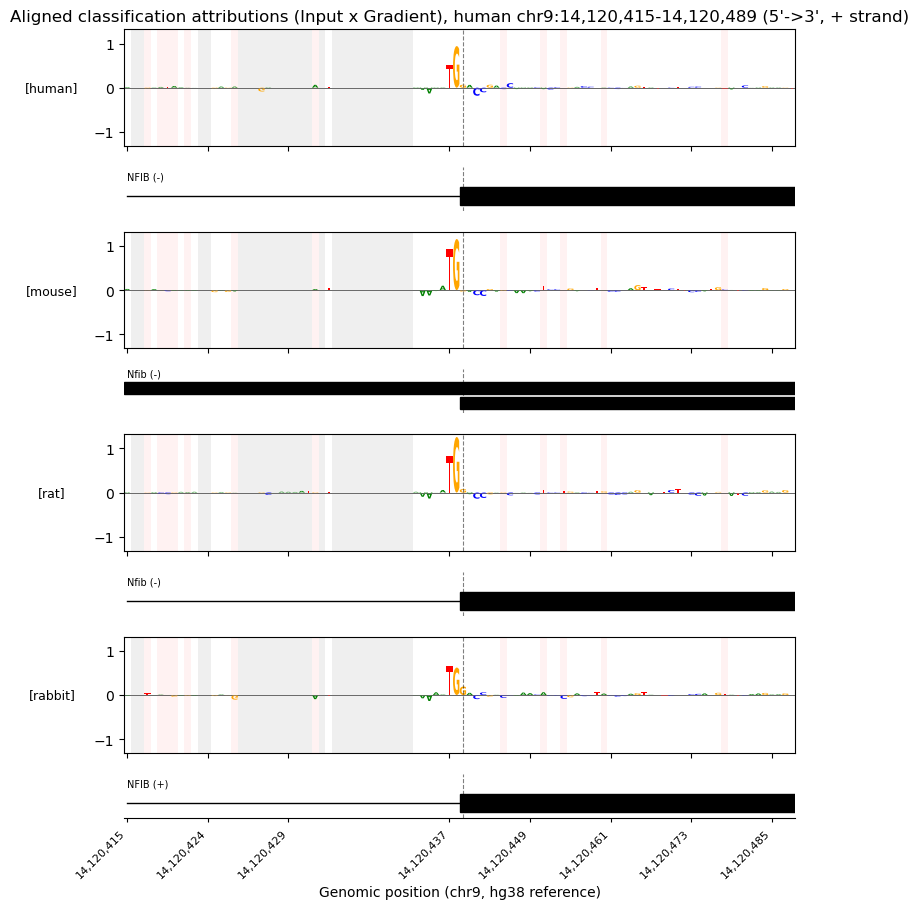

[FASTA] Wrote 4 aligned sequences (100 columns) to /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/maf_cache/aligned_classification_9_14120439.fasta
[PDF] Saved /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/lora_32_human_mouse_rat_rabbit_opossum/attributions/aligned_usage_9_14120439_Brain_12.pdf


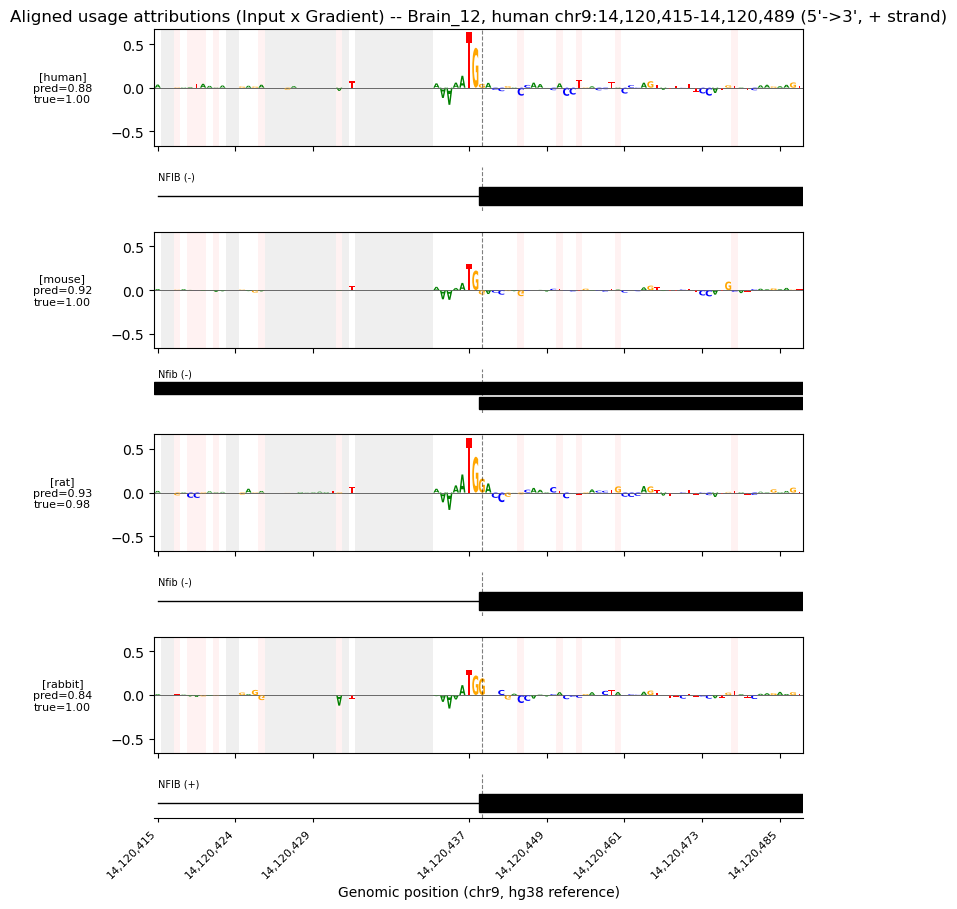

[FASTA] Wrote 4 aligned sequences (100 columns) to /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/maf_cache/aligned_usage_9_14120439_Brain_12.fasta
[PDF] Saved /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/lora_32_human_mouse_rat_rabbit_opossum/attributions/aligned_usage_9_14120439_Brain_2.pdf


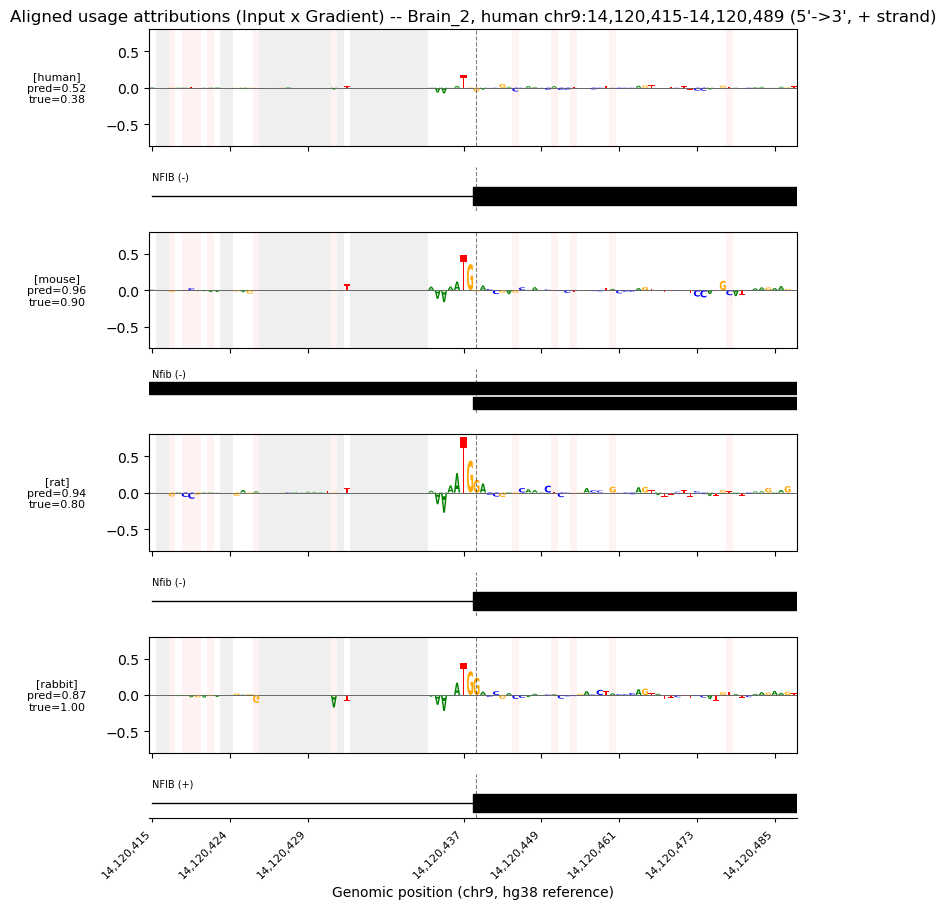

[FASTA] Wrote 4 aligned sequences (100 columns) to /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/maf_cache/aligned_usage_9_14120439_Brain_2.fasta
[PDF] Saved /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/lora_32_human_mouse_rat_rabbit_opossum/attributions/trajectories_9_14120439.pdf


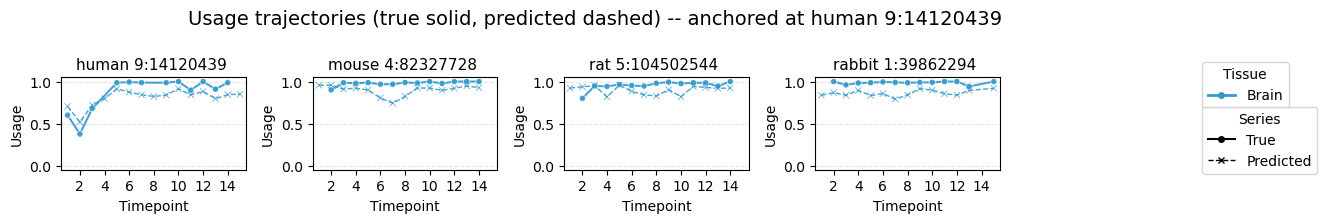

In [36]:
for entry in all_site_results:
    human_site, sites, maf_blocks, site_results = (
        entry["human_site"], entry["sites"], entry["maf_blocks"], entry["site_results"]
    )
    plot_aligned_classification_attributions(site_results, human_site, ALIGNED_SPECIES, maf_blocks, window=50, shared_strand_label="+")
    plot_aligned_usage_attributions(site_results, human_site, ALIGNED_SPECIES, maf_blocks, window=50, shared_strand_label="+")
    plot_usage_trajectories(site_results, sites, human_site, tissue_subset="Brain")


In [26]:
# Compare attributions
entry = all_site_results[0]
ref_pos = entry["human_site"]["position"]
compare_label = 'Brain_2'
compare_window = 500
divergence_df = compare_usage_attribution_across_species(
    entry["site_results"], entry["human_site"], ALIGNED_SPECIES, entry["maf_blocks"],
    label=compare_label, window=compare_window, top_n=200,
)
# Exclude positions around splice site
#x = 5
#divergence_df = divergence_df[~divergence_df["human_ref_position"].between(ref_pos - x, ref_pos + x)]
#left_sites = len(divergence_df)
#divr_sites = len(divergence_df[~divergence_df["conserved"]])
#print(f"[{compare_label}] Top {left_sites} highest-attribution-spread columns (excluding ±{x}bp around splice site): {divr_sites}/{left_sites} also have a diverged (non-conserved) base.")

[Brain_2] Top 200 highest-attribution-spread columns: 54/200 also have a diverged (non-conserved) base.


In [27]:
# Human's Brain_2 prediction (true=0.38, pred=0.52) differs from the other three
# species (true/pred > 0.8) -- find which positions specifically explain HUMAN being
# the outlier, rather than any pairwise disagreement among the four species.
human_vs_others_df = compare_species_vs_others(
    entry["site_results"], entry["human_site"], ALIGNED_SPECIES, entry["maf_blocks"],
    label=compare_label, focus_species="human", window=compare_window, top_n=100,
)
display(human_vs_others_df)

[Brain_2] Top 100 columns by |human vs. others| attribution difference: 0/100 also have a human-specific substitution/indel (every other species agrees on the base, human differs).


,alignment_column,human_ref_position,conserved,attribution_spread,human_attribution,human_base,mouse_attribution,mouse_base,rat_attribution,rat_base,rabbit_attribution,rabbit_base,human_vs_others_diff,others_agree_focus_differs
0,408,14120437,True,0.593750,0.167969,A,0.482422,A,0.761719,A,0.437500,A,-0.392578,False
1,407,14120438,True,0.432861,0.006592,C,0.357422,C,0.439453,C,0.326172,C,-0.367757,False
2,406,14120439,True,0.294189,-0.054932,C,-0.017822,C,0.172852,C,0.239258,C,-0.186361,False
3,409,14120436,True,0.240234,0.025391,T,0.117676,T,0.265625,T,0.168945,T,-0.158691,False
4,411,14120434,True,0.197266,-0.078125,T,-0.165039,T,-0.275391,T,-0.218750,T,0.141602,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,446,14120423,True,0.034180,0.007568,T,-0.025513,T,0.003662,T,-0.026611,T,0.023722,False
96,302,14120543,True,0.029205,0.007233,A,-0.010437,A,-0.016357,A,-0.021973,A,0.023488,False
97,252,14120590,True,0.056458,0.013367,G,0.015320,G,0.069824,G,0.025146,G,-0.023397,False
98,541,14120375,False,0.036499,-0.008423,G,0.004547,A,0.028076,G,0.012085,G,-0.023326,False



[Brain_2] human vs. others -- stretch 1/3: chr9:14,120,397-14,120,400 (4 columns, total_diff=0.109, 0% of columns have a human-specific substitution/indel)
[PDF] Saved /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/lora_32_human_mouse_rat_rabbit_opossum/attributions/divergent_region_9_14120398_Brain_2.pdf


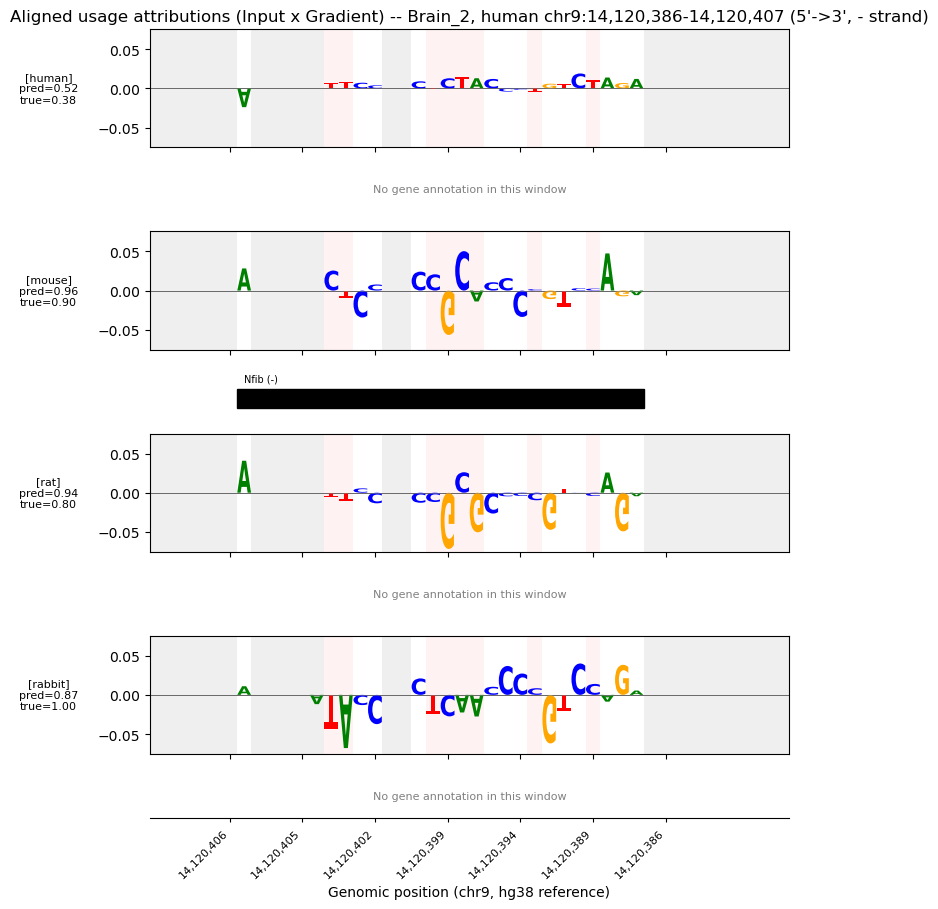


[Brain_2] human vs. others -- stretch 2/3: chr9:14,120,717-14,120,721 (5 columns, total_diff=-0.040, 0% of columns have a human-specific substitution/indel)
[PDF] Saved /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/lora_32_human_mouse_rat_rabbit_opossum/attributions/divergent_region_9_14120719_Brain_2.pdf


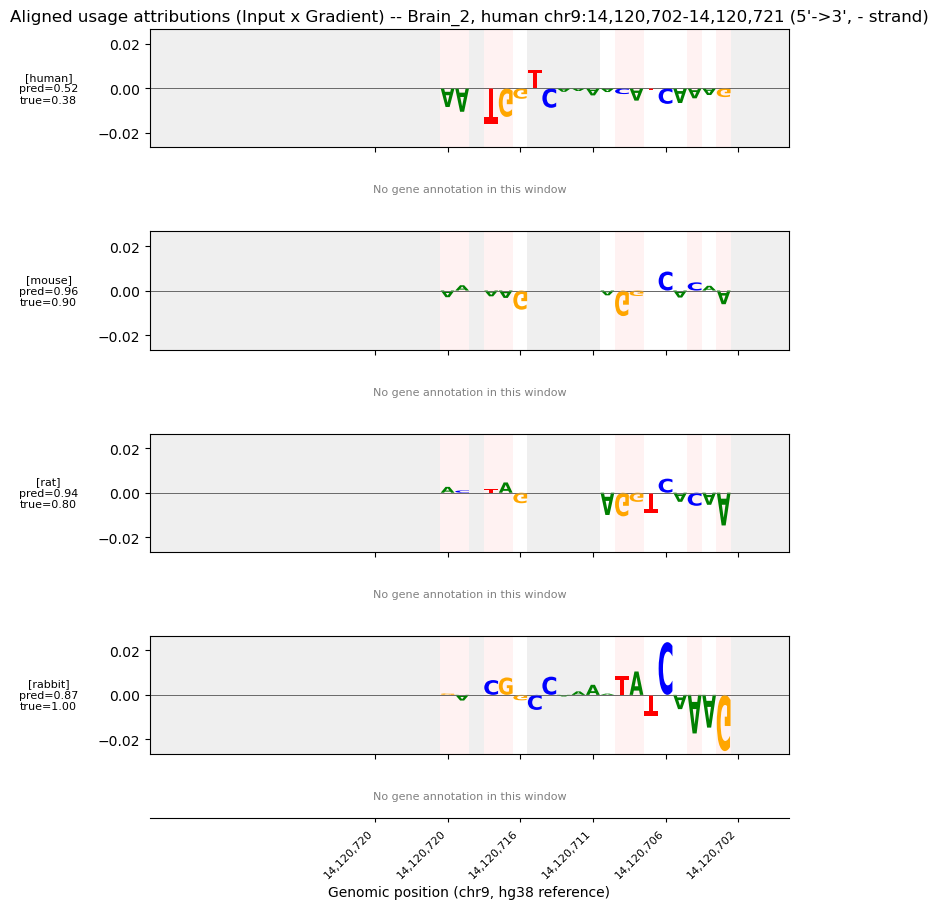


[Brain_2] human vs. others -- stretch 3/3: chr9:14,120,322-14,120,325 (4 columns, total_diff=0.035, 25% of columns have a human-specific substitution/indel)
[PDF] Saved /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/lora_32_human_mouse_rat_rabbit_opossum/attributions/divergent_region_9_14120323_Brain_2.pdf


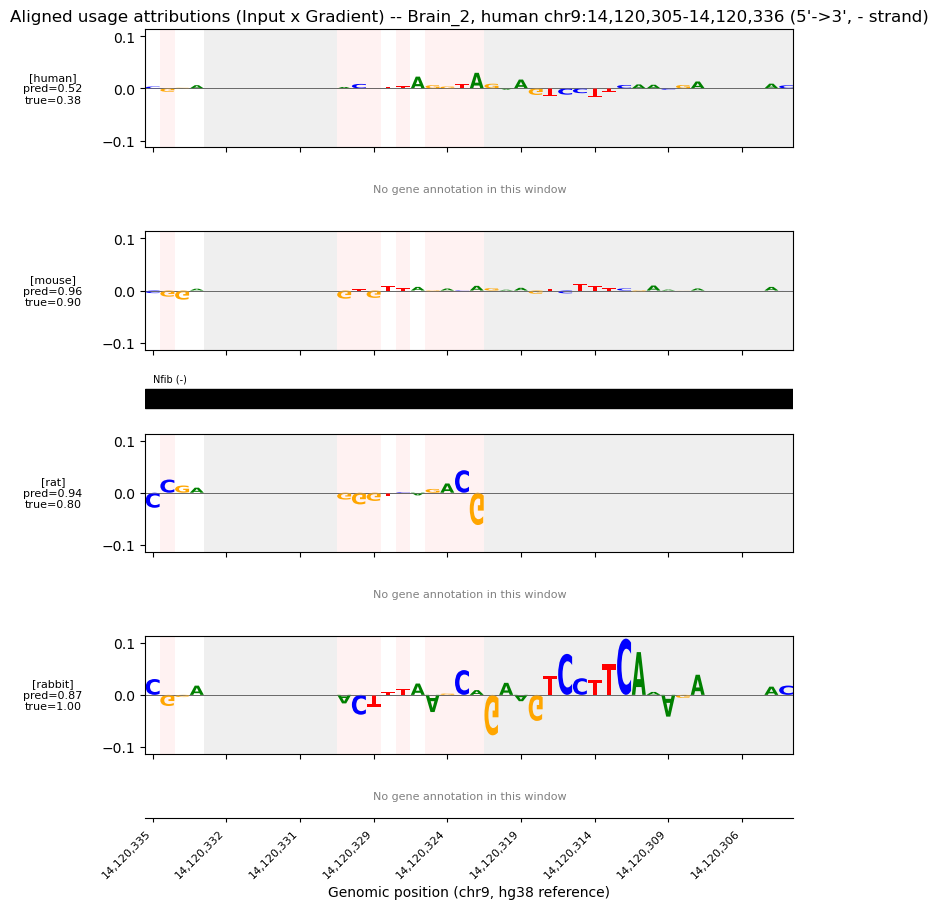

In [25]:
# Identify contiguous stretches of diverged columns where HUMAN's attribution differs
# most from the other species, and plot each (zoomed, with context) 
# as an aligned usage-attribution logo plot.
human_vs_others_stretches = plot_top_species_vs_others_stretches(
    entry["site_results"], entry["human_site"], ALIGNED_SPECIES, entry["maf_blocks"],
    label=compare_label, focus_species="human", 
    window=compare_window, min_length=4, top_n=3, context_columns=20,
)

In [22]:
# Validate the top-ranked position causally: swap human's base there for the other
# species' consensus base, and see whether that alone shifts the Brain_2 prediction.
swap_result = run_sequence_swap_experiment(
    entry["site_results"], entry["human_site"], model, device,
    human_vs_others_df, label=compare_label, row_index=0,
)

[Brain_2] Swap human C->G at chr9:14,120,399 (other species: ['G', 'G', 'C']):
  classification: Donor- (p=0.969) -> Donor- (p=0.969)
  usage (Brain_2): 0.516 -> 0.514


In [ ]:
# The single top-ranked position isn't guaranteed to be the one that matters causally --
# check the top candidate positions independently and rank them by how much each one
# alone shifts the Brain_2 usage prediction.
swap_results_df = run_top_sequence_swap_experiments(
    entry["site_results"], entry["human_site"], model, device,
    human_vs_others_df, label=compare_label, top_n=10,
)
display(swap_results_df.sort_values("usage_shift", key=abs, ascending=False))


[Brain_2] Swap human C->G at chr9:14,120,399 (other species: ['G', 'G', 'C']):
  classification: Donor- (p=0.969) -> Donor- (p=0.969)
  usage (Brain_2): 0.516 -> 0.514
[Brain_2] Swap human C->G at chr9:14,120,399 (other species: ['G', 'G', 'C']):
  classification: Donor- (p=0.969) -> Donor- (p=0.969)
  usage (Brain_2): 0.516 -> 0.514
[Brain_2] Swap human T->C at chr9:14,120,648 (other species: ['C', 'C', 'T']):
  classification: Donor- (p=0.969) -> Donor- (p=0.969)
  usage (Brain_2): 0.516 -> 0.515


,ref_position,old_base,new_base,other_species_bases,original_pred_class,swapped_pred_class,original_pred_prob,swapped_pred_prob,original_usage_pred,swapped_usage_pred,usage_shift
0,14120399,C,G,"[G, G, C]",Donor-,Donor-,0.96875,0.96875,0.516347,0.513578,-0.002769
1,14120648,T,C,"[C, C, T]",Donor-,Donor-,0.96875,0.96875,0.516347,0.515131,-0.001216


[Brain_2] Swapped 3/4 position(s) in chr9:14,120,397-14,120,400: T->C@14,120,400, C->G@14,120,399, T->C@14,120,398
  classification: Donor- (p=0.969) -> Donor- (p=0.973)
  usage (Brain_2): 0.516 -> 0.495  (shift=-0.021)


In [ ]:
# If no single base swap moves the prediction, try swapping the WHOLE top diverged
# stretch simultaneously -- the combined effect of the segment might matter even when
# no individual position does.
if human_vs_others_stretches:
    stretch_swap_result = run_stretch_swap_experiment(
        entry["site_results"], entry["human_site"], ALIGNED_SPECIES, entry["maf_blocks"],
        label=compare_label, model=model, device=device, stretch=human_vs_others_stretches[0],
        window=compare_window,
    )
else:
    print("No diverged stretches found for this label; nothing to swap as a segment.")


## Notes

- **Cost**: each attribution call runs at least one full forward+backward pass
  through the model at the full 131 kb input length, far more expensive than
  plain inference. Integrated Gradients / SmoothGrad multiply that cost by
  `steps` / `num_samples` respectively — keep those small (5-20) for
  interactive use. Cost scales linearly with the number of species per site,
  times the number of entries in `HUMAN_SITES`.
- **MAF scan cost**: the *first* time you look up a given human site, deriving
  `ALIGNED_SPECIES` positions requires a reference-ordered streaming scan of
  that chromosome's multiz100way `.maf.gz`, which can take 10+ minutes for a
  locus deep into a large chromosome. Subsequent runs reuse the cache under
  `MAF_CACHE_DIR` and are instant.
- **Target choice**: `classification_target` / `usage_target` operate on the
  raw *logits*, not the post-softmax/sigmoid predictions, so attributions
  reflect the model's linear output scale rather than a saturated non-linearity.
- **Method choice**: classification and usage attributions both use
  `ATTRIBUTION_METHOD` (`"integrated_gradients"` — the standard, better-justified
  choice for one-hot inputs, path integral from an all-zero baseline — or
  `"input_x_gradient"`, a cheap one-pass approximation). The SmoothGrad section
  compares whichever was chosen against `smoothgrad` for the classification
  target only.
- To attribute a different (or additional) human locus, edit `HUMAN_SITES`
  (Configuration cell) — each entry is one locus (chrom/position/strand) plus its
  own `condition_name`/`tissue_name` usage-attribution filter; `ALIGNED_SPECIES`'
  positions are re-derived automatically from the alignment per site, not given
  manually. `HUMAN_SPECIES` (genome/annotation/usage/gene-model paths) and
  `ALIGNED_SPECIES` are shared across every `HUMAN_SITES` entry, not repeated per
  site. To compare against a different species, add an entry to `ALIGNED_SPECIES`
  with its UCSC `maf_id` (e.g. `"mm10"` for mouse, `"rn6"` for rat, `"monDom5"` for
  opossum — all present alongside `oryCun2` in this checkpoint's species). To use a
  different model, swap `CHECKPOINT_DIR` — everything downstream is generic to
  `alphagenome_pytorch.attributions`.
